# Analysis Results

## 1D-Ising Chain

### $\tau$ hyperparameter

#### F-CRAB case

##### Data

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

# ── load ──────────────────────────────────────────────────────────────────────
with open("results/study_vs_tau_n6_np5.pkl", "rb") as f:
    data = pickle.load(f)

results = data["results"]  # list of dicts, one per tau
taus = data["taus"]  # [1.0, 2.0, 5.0, 10.0, 20.0, 50.0]

# ── single result ─────────────────────────────────────────────────────────────
r = results[3]  # e.g. tau=10
time = r["time"]

# trajectories
magic_lin = r["magic_lin"]  # M2 along linear evolution
magic_opt = r["magic_opt"]  # M2 along optimal control
magic_gs = r["magic_gs"]  # M2 of instantaneous GS (adiabatic ref)
ee_lin = r["ee_lin"]  # EE along linear
ee_opt = r["ee_opt"]  # EE along optimal
ee_gs = r["ee_gs"]  # EE of instantaneous GS

# schedules
h_driver = r["h_driver_opt"]
h_target = r["h_target_opt"]

# scalars
fidelity_lin = r["fidelity_lin"]
fidelity_opt = r["fidelity_opt"]
int_magic_lin = r["int_magic_lin"]  # ∫ M2 dt linear
int_magic_opt = r["int_magic_opt"]  # ∫ M2 dt optimal
int_ee_lin = r["int_ee_lin"]
int_ee_opt = r["int_ee_opt"]

# optimizer convergence history
opt_history = [r["opt_energy_history"] for r in results]

# ── scalar quantities vs tau ───────────────────────────────────────────────────
fidelities_lin = [r["fidelity_lin"] for r in results]
fidelities_opt = [r["fidelity_opt"] for r in results]
int_magic_lins = [r["int_magic_lin"] for r in results]
int_magic_opts = [r["int_magic_opt"] for r in results]
int_magic_gss = [r["int_magic_gs"] for r in results]
int_ee_lins = [r["int_ee_lin"] for r in results]
int_ee_opts = [r["int_ee_opt"] for r in results]
int_ee_gss = [r["int_ee_gs"] for r in results]
min_gaps = [r["min_gap"] for r in results]

##### Magic

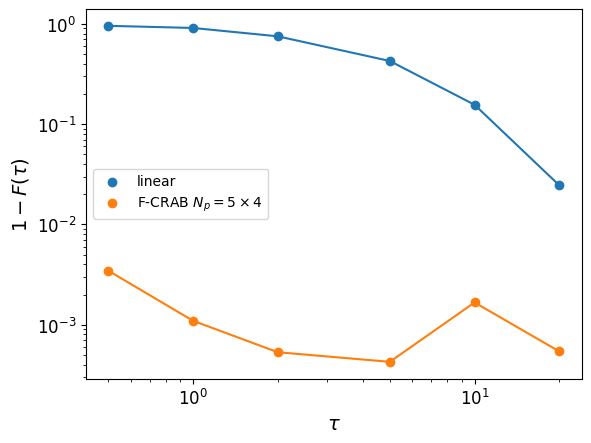

In [2]:
plt.plot(
    taus,
    1 - np.asarray(fidelities_lin),
)
plt.scatter(taus, 1 - np.asarray(fidelities_lin), label="linear", color="C0")
plt.plot(
    taus,
    1 - np.asarray(fidelities_opt),
)
plt.scatter(
    taus, 1 - np.asarray(fidelities_opt), label=r"F-CRAB $N_p=5 \times 4$", color="C1"
)
plt.xlabel(r"$\tau$", fontsize=14)
plt.ylabel(r"$1-F(\tau)$", fontsize=14)
plt.xscale("log")
plt.yscale("log")
plt.tick_params(labelsize=12)
plt.legend()
plt.show()

##### Losses

[-0.8804029447625693, -1.4260674555887938, -2.00640010125504, -2.5720786050168725, -2.791375093967228, -2.9704987988783955, -3.2795727951482467, -3.573310746926034, -3.823885668825562, -4.373527794993027, -4.648266129693926, -4.919184150662309, -5.001863251737222, -5.069364099694924, -5.2127282580091805, -5.354302258685687, -5.481913616785891, -5.584867129468939, -5.670071997190844, -5.679783114678931, -5.6903557814840315, -5.719396473765049, -5.737683634332196, -5.760826693395265, -5.780143630824945, -5.803362367883634, -5.83347368658336, -5.8706607761073775, -5.896472758878025, -5.919290372187072, -5.923992965701516, -5.936296236945005, -5.941595774166529, -5.953346119267187, -5.961332724468282, -5.968676241591428, -5.972000321430145, -5.97252802201323, -5.972870057663839, -5.974608492092237, -5.976490634697706, -5.979674869428492, -5.980951667175825, -5.981623787631165, -5.982028197749256, -5.982308705360454, -5.9834052938811615, -5.984306955688536, -5.9845229711612005, -5.984696977

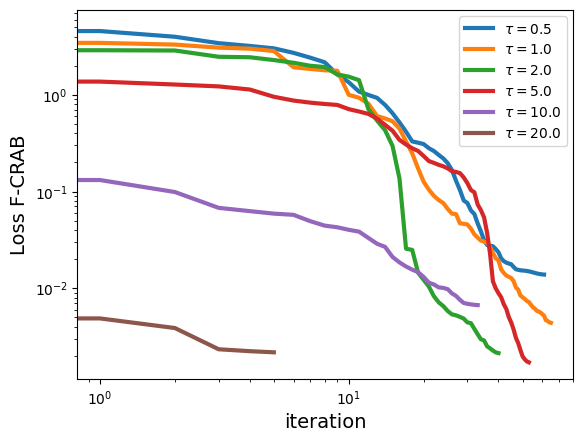

In [6]:
for hist in opt_history:
    print(hist)
    plt.plot(
        6 + np.array(hist),
        linewidth=3,
        label=r"$\tau={:.1f}$".format(taus[opt_history.index(hist)]),
    )
plt.xlabel("iteration", fontsize=14)
plt.ylabel("Loss F-CRAB", fontsize=14)
plt.legend()
plt.yscale("log")
plt.xscale("log")
plt.show()

##### Cumulative Magic per time evolution

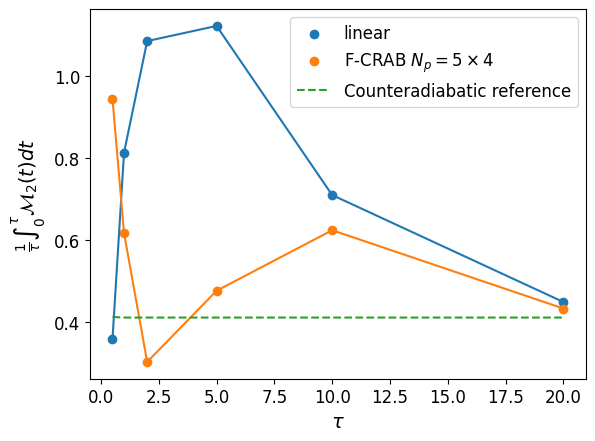

In [23]:
plt.plot(taus, np.array(int_magic_lins) / np.array(taus), color="C0")
plt.scatter(
    taus,
    np.array(int_magic_lins) / np.array(taus),
    label="linear",
    color="C0",
)
plt.plot(taus, np.array(int_magic_opts) / np.array(taus), color="C1")
plt.scatter(
    taus,
    np.array(int_magic_opts) / np.array(taus),
    label=r"F-CRAB $N_p=5 \times 4$",
    color="C1",
)

plt.plot(
    taus,
    np.array(int_magic_gss) / np.array(taus),
    color="C2",
    label=r"Counteradiabatic reference",
    linestyle="--",
)


plt.xlabel(r"$\tau$", fontsize=14)
plt.ylabel(r"$\frac{1}{\tau} \int_0^\tau \mathcal{M}_2(t) dt$", fontsize=14)

plt.tick_params(labelsize=12)
plt.legend(fontsize=12)
plt.show()

##### Entanglement Production

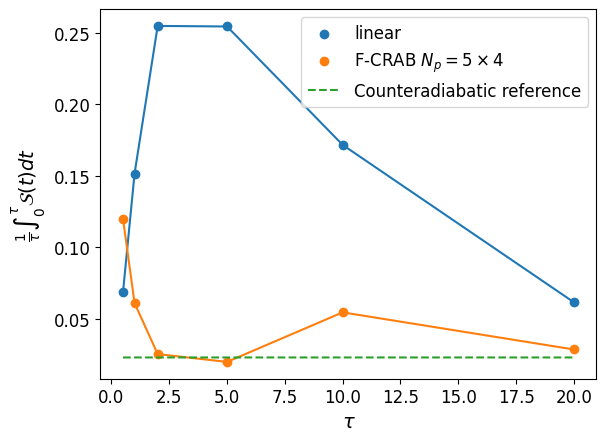

In [7]:
plt.plot(taus, np.array(int_ee_lins) / np.array(taus), color="C0")
plt.scatter(
    taus,
    np.array(int_ee_lins) / np.array(taus),
    label="linear",
    color="C0",
)
plt.plot(taus, np.array(int_ee_opts) / np.array(taus), color="C1")
plt.scatter(
    taus,
    np.array(int_ee_opts) / np.array(taus),
    label=r"F-CRAB $N_p=5 \times 4$",
    color="C1",
)

plt.plot(
    taus,
    np.array(int_ee_gss) / np.array(taus),
    color="C2",
    label=r"Counteradiabatic reference",
    linestyle="--",
)


plt.xlabel(r"$\tau$", fontsize=14)
plt.ylabel(r"$\frac{1}{\tau} \int_0^\tau \mathcal{S}(t) dt$", fontsize=14)

plt.tick_params(labelsize=12)
plt.legend(fontsize=12)
plt.show()

#### Fourier Case

##### Data

In [61]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

# ── load ──────────────────────────────────────────────────────────────────────
with open("results/study_vs_tau_n6_np5_fourier.pkl", "rb") as f:
    data = pickle.load(f)

results = data["results"]  # list of dicts, one per tau
taus = data["taus"]  # [1.0, 2.0, 5.0, 10.0, 20.0, 50.0]

# ── single result ─────────────────────────────────────────────────────────────
r = results[3]  # e.g. tau=10
time = r["time"]

# trajectories
magic_lin = r["magic_lin"]  # M2 along linear evolution
magic_opt = r["magic_opt"]  # M2 along optimal control
magic_gs = r["magic_gs"]  # M2 of instantaneous GS (adiabatic ref)
ee_lin = r["ee_lin"]  # EE along linear
ee_opt = r["ee_opt"]  # EE along optimal
ee_gs = r["ee_gs"]  # EE of instantaneous GS

# schedules
h_driver = r["h_driver_opt"]
h_target = r["h_target_opt"]

# scalars
fidelity_lin = r["fidelity_lin"]
fidelity_opt = r["fidelity_opt"]
int_magic_lin = r["int_magic_lin"]  # ∫ M2 dt linear
int_magic_opt = r["int_magic_opt"]  # ∫ M2 dt optimal
int_ee_lin = r["int_ee_lin"]
int_ee_opt = r["int_ee_opt"]

# optimizer convergence history
opt_history = [r["opt_energy_history"] for r in results]

# ── scalar quantities vs tau ───────────────────────────────────────────────────
fidelities_lin = [r["fidelity_lin"] for r in results]
fidelities_opt = [r["fidelity_opt"] for r in results]
int_magic_lins = [r["int_magic_lin"] for r in results]
int_magic_opts = [r["int_magic_opt"] for r in results]
int_magic_gss = [r["int_magic_gs"] for r in results]
int_ee_lins = [r["int_ee_lin"] for r in results]
int_ee_opts = [r["int_ee_opt"] for r in results]
int_ee_gss = [r["int_ee_gs"] for r in results]
min_gaps = [r["min_gap"] for r in results]

##### Magic

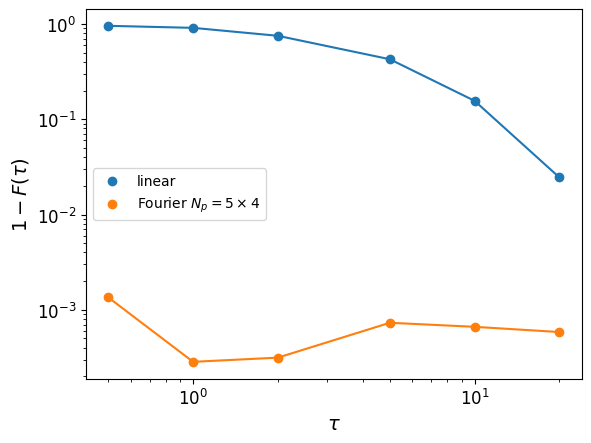

In [63]:
plt.plot(
    taus,
    1 - np.asarray(fidelities_lin),
)
plt.scatter(taus, 1 - np.asarray(fidelities_lin), label="linear", color="C0")
plt.plot(
    taus,
    1 - np.asarray(fidelities_opt),
)
plt.scatter(
    taus, 1 - np.asarray(fidelities_opt), label=r"Fourier $N_p=5 \times 4$", color="C1"
)
plt.xlabel(r"$\tau$", fontsize=14)
plt.ylabel(r"$1-F(\tau)$", fontsize=14)
plt.xscale("log")
plt.yscale("log")
plt.tick_params(labelsize=12)
plt.legend()
plt.show()

Analysis of the probs for a fixed $\tau$

(20,)


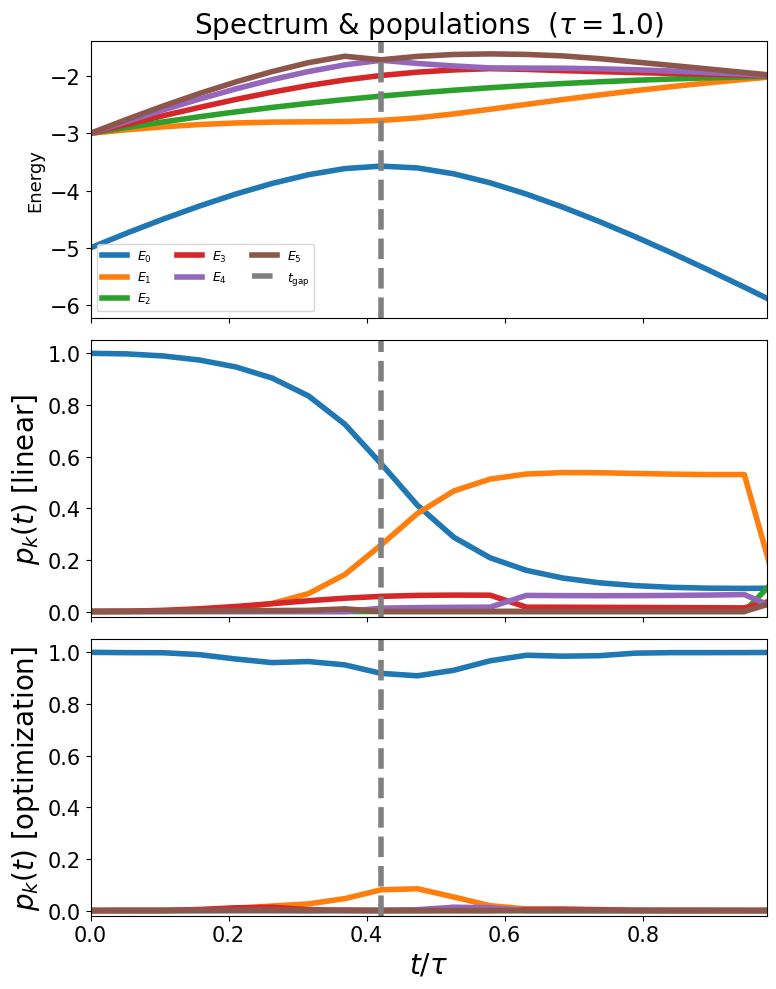

In [16]:
import numpy as np
import matplotlib.pyplot as plt

idx_tau = 1

r = results[idx_tau]  # pick your tau
time = r["time"]

print(time.shape)
spectrum = r["spectrum"]  # (time_steps, nlevels)
probs_lin = r["probs_lin"]  # (time_steps, nlevels)
probs_opt = r["probs_opt"]  # (time_steps, nlevels)
t_gap = r["t_min_gap"]
nlevels = spectrum.shape[1]  # 6

colors = [f"C{k}" for k in range(nlevels)]
labels = [r"$E_0$", r"$E_1$", r"$E_2$", r"$E_3$", r"$E_4$", r"$E_5$"]

fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

# ── top: energy spectrum ───────────────────────────────────────────────────────
ax = axes[0]
for k in range(nlevels):
    ax.plot(
        time / taus[idx_tau], spectrum[:, k], color=colors[k], lw=4, label=labels[k]
    )
ax.axvline(t_gap / taus[idx_tau], color="gray", ls="--", lw=4, label=r"$t_{\rm gap}$")
ax.set_ylabel("Energy", fontsize=13)
ax.legend(ncol=3, fontsize=9)
ax.set_title(rf"Spectrum & populations  ($\tau={r['tau']:.1f}$)", fontsize=20)
ax.set_xlim([0, 0.98])
ax.tick_params(labelsize=15)

# ── middle: populations — linear ───────────────────────────────────────────────
ax = axes[1]
for k in range(nlevels):
    ax.plot(
        time / taus[idx_tau], probs_lin[:, k], color=colors[k], lw=4, label=labels[k]
    )
ax.axvline(t_gap / taus[idx_tau], color="gray", ls="--", lw=4)
ax.set_ylabel(r"$p_k(t)$ [linear]", fontsize=20)
ax.set_ylim(-0.02, 1.05)
ax.set_xlim([0, 0.98])
ax.tick_params(labelsize=15)
# ── bottom: populations — optimal control ──────────────────────────────────────
ax = axes[2]
for k in range(nlevels):
    ax.plot(
        (time) / taus[idx_tau],
        probs_opt[:, k],
        color=colors[k],
        lw=4,
        label=labels[k],
    )
ax.axvline(t_gap / taus[idx_tau], color="gray", ls="--", lw=4)
ax.set_ylabel(r"$p_k(t)$ [optimization]", fontsize=20)
ax.set_ylim(-0.02, 1.05)
ax.set_xlabel(r"$t/\tau$", fontsize=20)
ax.set_xlim([0, 0.98])
ax.tick_params(labelsize=15)

plt.tight_layout()
plt.show()

Comparison with all the $\tau$

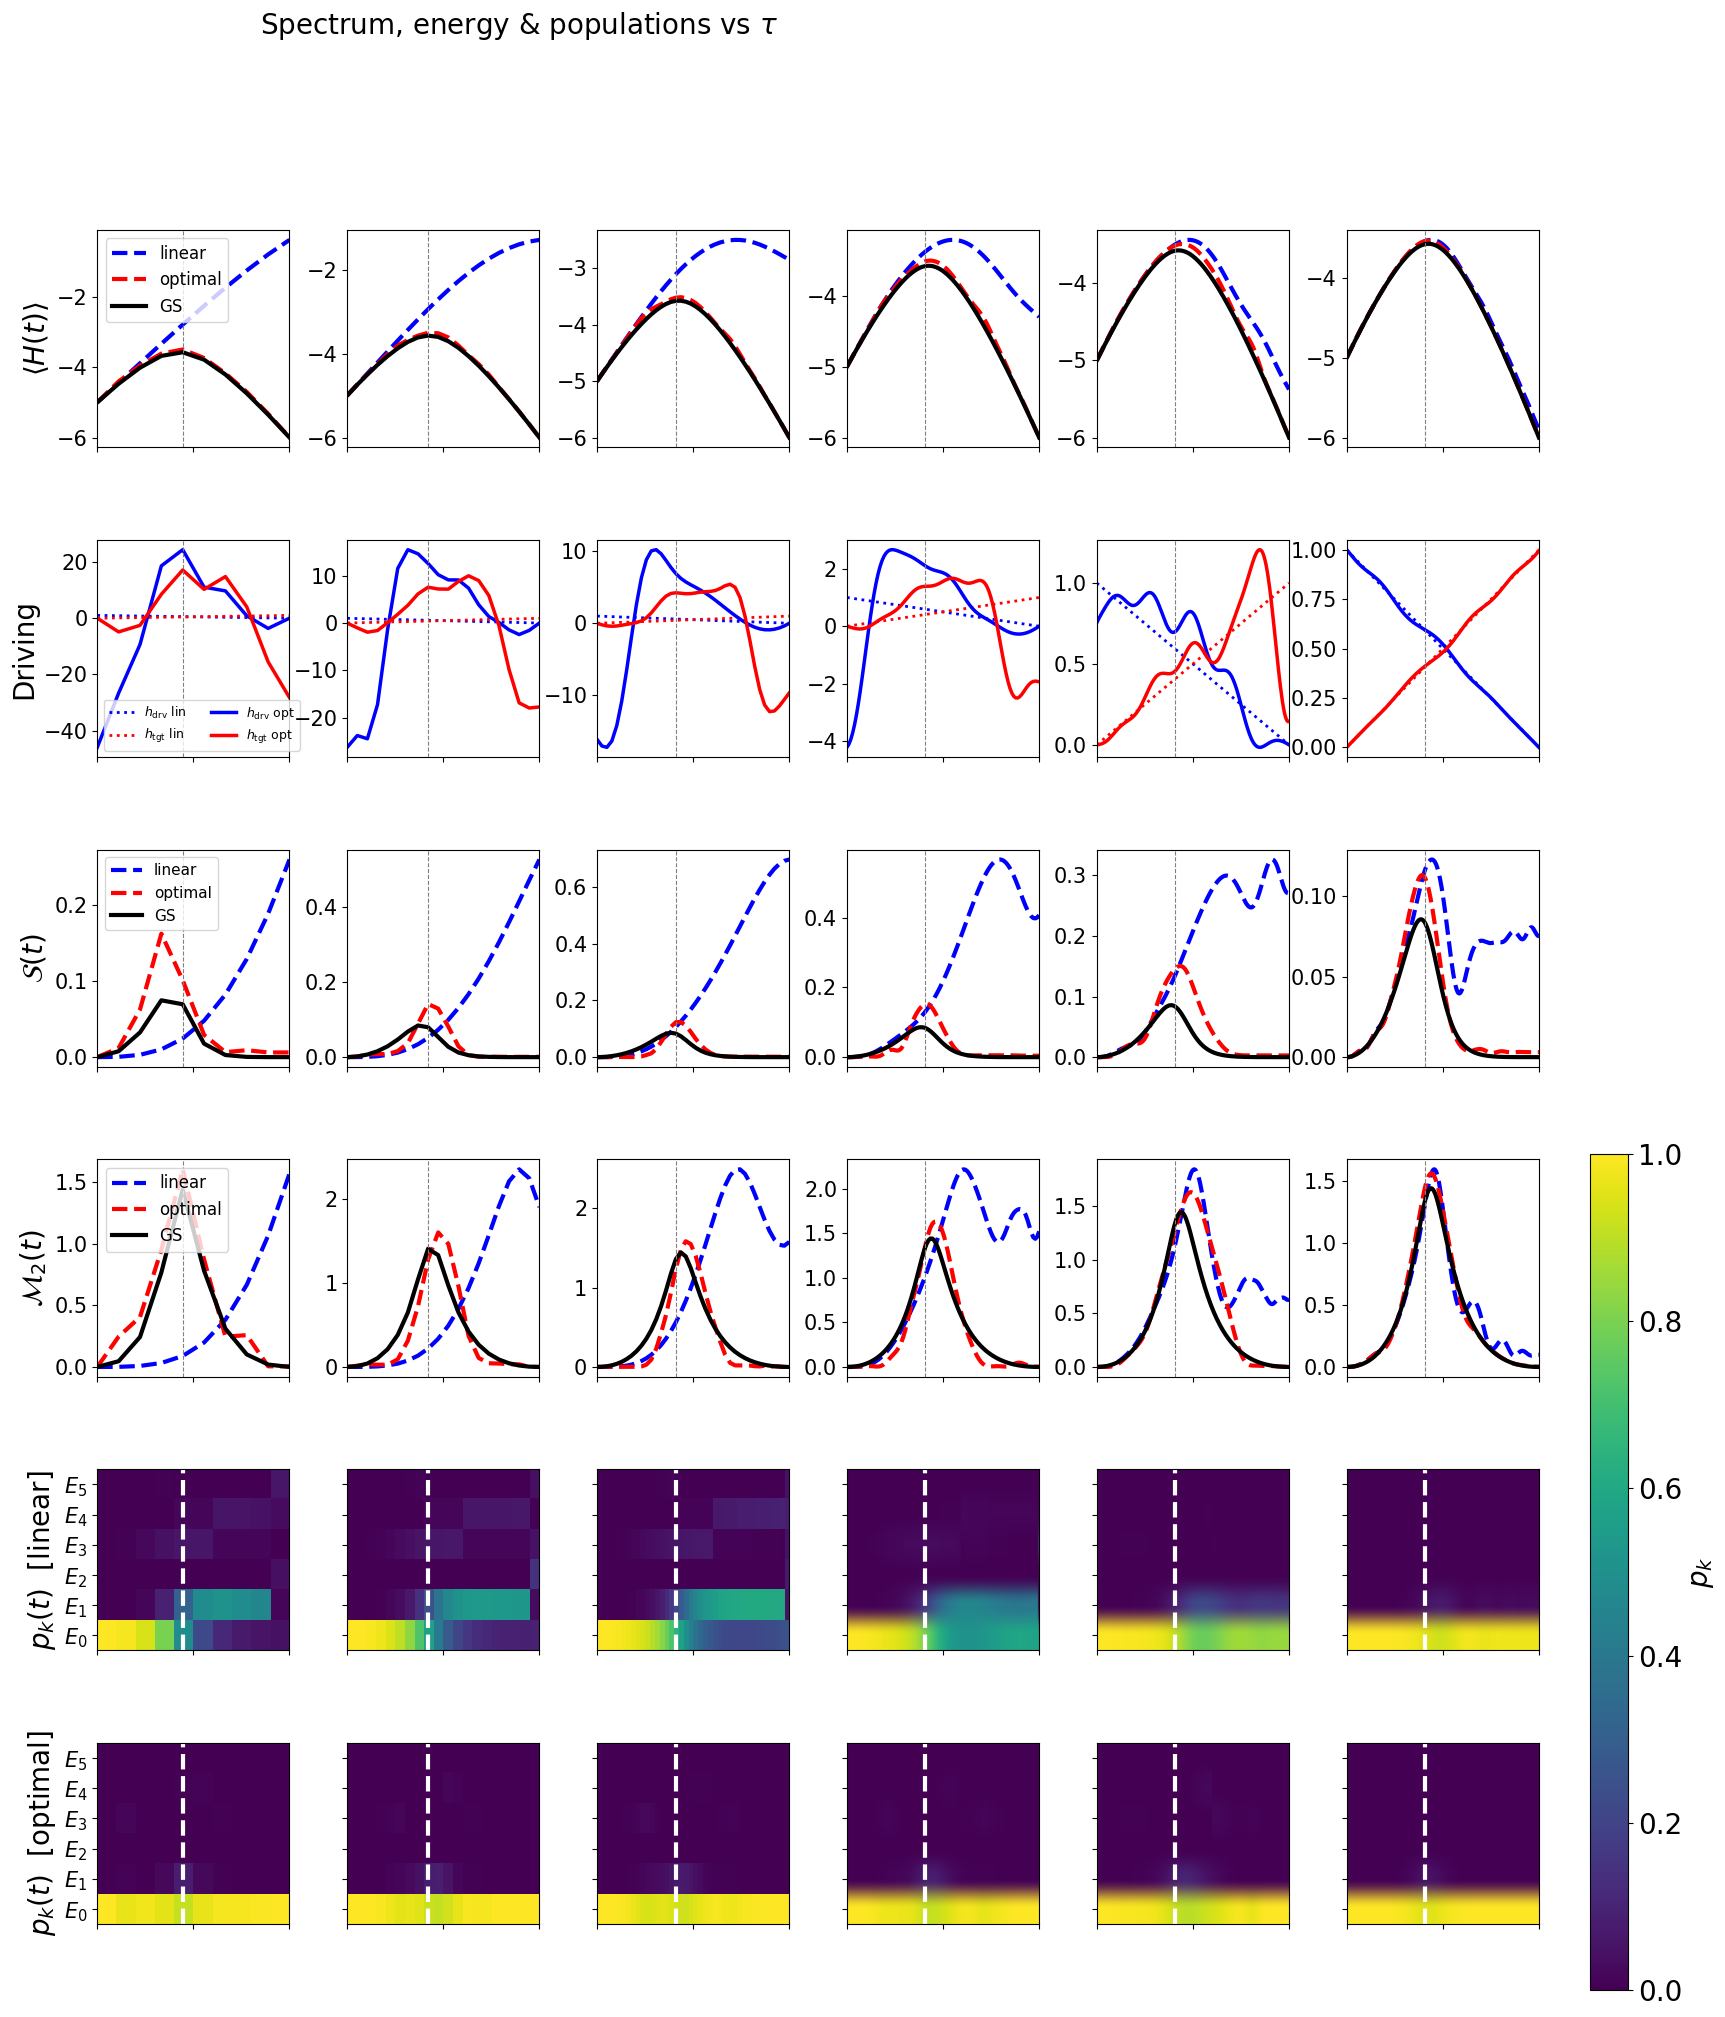

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# ── config ────────────────────────────────────────────────────────────────────
nlevels = results[0]["spectrum"].shape[1]
colors = [f"C{k}" for k in range(nlevels)]
labels = [rf"$E_{k}$" for k in range(nlevels)]
n_taus = len(results)

# ── figure layout ─────────────────────────────────────────────────────────────
# Left column : single spectrum plot (shared across all τ)
# Right block : n_taus columns × 6 rows
#   Row 0: energy E(t)
#   Row 1: drivings h_driver / h_target   ← NEW
#   Row 2: entanglement entropy EE(t)
#   Row 3: magic M2(t)
#   Row 4-5: heatmaps p_k(t/tau) lin / opt
fig = plt.figure(figsize=(1.5 + 4 * n_taus, 22))
outer = gridspec.GridSpec(1, 2, width_ratios=[1, n_taus], wspace=0.35)


# ── right block: 6 rows × n_taus cols ────────────────────────────────────────
gs = gridspec.GridSpecFromSubplotSpec(
    6,
    n_taus,
    subplot_spec=outer[1],
    height_ratios=[1.2, 1.2, 1.2, 1.2, 1, 1],
    hspace=0.45,
    wspace=0.3,
)

# ── row 1: energy E(t) = <psi|H(t)|psi> for lin and opt ─────────────────────
for j, (r, tau) in enumerate(zip(results, taus)):
    ax = fig.add_subplot(gs[0, j])
    t = r["time"] / tau
    e0 = r["spectrum"][:, 0]  # instantaneous GS energy
    ax.plot(t, r["energy_lin"], color="blue", lw=3, ls="--", label="linear")
    ax.plot(t, r["energy_opt"], color="red", ls="--", lw=3, label="optimal")
    ax.plot(t, e0, color="k", lw=3, ls="-", label="GS")
    ax.axvline(r["t_min_gap"] / tau, color="gray", ls="--", lw=0.8)
    ax.set_xlim(0, 1)
    if j == 0:
        ax.set_ylabel(r"$\langle H(t)\rangle$", fontsize=20)
        ax.legend(fontsize=12)
    ax.tick_params(labelsize=15)
    ax.set_xticklabels([])


# ── row 1: drivings h_driver / h_target ──────────────────────────────────────
for j, (r, tau) in enumerate(zip(results, taus)):
    ax = fig.add_subplot(gs[1, j])
    t = r["time"] / tau
    # linear schedule (analytical ramp)
    ax.plot(t, 1 - t, color="blue", lw=2, ls=":", label=r"$h_\mathrm{drv}$ lin")
    ax.plot(t, t, color="red", lw=2, ls=":", label=r"$h_\mathrm{tgt}$ lin")
    # optimal schedule
    ax.plot(
        t,
        r["h_driver_opt"],
        color="blue",
        lw=2.5,
        ls="-",
        label=r"$h_\mathrm{drv}$ opt",
    )
    ax.plot(
        t, r["h_target_opt"], color="red", lw=2.5, ls="-", label=r"$h_\mathrm{tgt}$ opt"
    )
    ax.axvline(r["t_min_gap"] / tau, color="gray", ls="--", lw=0.8)
    ax.set_xlim(0, 1)
    if j == 0:
        ax.set_ylabel("Driving", fontsize=20)
        ax.legend(fontsize=9, ncol=2)
    ax.tick_params(labelsize=15)
    ax.set_xticklabels([])


# ── row 1: entanglement entropy EE(t) ────────────────────────────────────────
for j, (r, tau) in enumerate(zip(results, taus)):
    ax = fig.add_subplot(gs[2, j])
    t = r["time"] / tau
    ax.plot(t, r["ee_lin"], color="blue", lw=3, ls="--", label="linear")
    ax.plot(t, r["ee_opt"], color="red", lw=3, ls="--", label="optimal")
    ax.plot(t, r["ee_gs"], color="k", lw=3, ls="-", label="GS")
    ax.axvline(r["t_min_gap"] / tau, color="gray", ls="--", lw=0.8)
    ax.set_xlim(0, 1)
    if j == 0:
        ax.set_ylabel(r"$\mathcal{S}(t)$", fontsize=20)
        ax.legend(fontsize=11)
    ax.tick_params(labelsize=15)
    ax.set_xticklabels([])


# ── row 2: magic M2(t) ───────────────────────────────────────────────────────
for j, (r, tau) in enumerate(zip(results, taus)):
    ax = fig.add_subplot(gs[3, j])
    t = r["time"] / tau
    ax.plot(t, r["magic_lin"], color="blue", lw=3, ls="--", label="linear")
    ax.plot(t, r["magic_opt"], color="red", lw=3, ls="--", label="optimal")
    ax.plot(t, r["magic_gs"], color="k", lw=3, ls="-", label="GS")
    ax.axvline(r["t_min_gap"] / tau, color="gray", ls="--", lw=0.8)
    ax.set_xlim(0, 1)
    if j == 0:
        ax.set_ylabel(r"$\mathcal{M}_2(t)$", fontsize=20)
        ax.legend(fontsize=12)
    ax.tick_params(labelsize=15)
    ax.set_xticklabels([])

# ── rows 3-4: heatmaps of p_k(t/tau) ─────────────────────────────────────────
for row_idx, (proto_key, proto_label) in enumerate(
    [("probs_lin", "linear"), ("probs_opt", "optimal")], start=4
):
    for j, (r, tau) in enumerate(zip(results, taus)):
        ax = fig.add_subplot(gs[row_idx, j])
        probs = r[proto_key].T  # (nlevels, time_steps)
        t = r["time"] / tau

        im = ax.imshow(
            probs,
            aspect="auto",
            origin="lower",
            extent=[t[0], t[-1], -0.5, nlevels - 0.5],
            vmin=0,
            vmax=1,
            cmap="viridis",
        )
        ax.axvline(r["t_min_gap"] / tau, color="white", ls="--", lw=3)
        ax.set_yticks(range(nlevels))
        ax.set_xlim(0, 1)
        if j == 0:
            ax.set_yticklabels([rf"$E_{k}$" for k in range(nlevels)], fontsize=8)
            ax.set_ylabel(r"$p_k(t)$ " + f" [{proto_label}]", fontsize=20)
        else:
            ax.set_yticklabels([])
        if row_idx == 3:
            ax.set_xlabel(r"$t/\tau$", fontsize=20)
        else:
            ax.set_xticklabels([])
        ax.tick_params(labelsize=15)

# shared colorbar for heatmaps
cbar_ax = fig.add_axes([0.92, 0.08, 0.015, 0.38])
cb = fig.colorbar(
    ScalarMappable(norm=Normalize(0, 1), cmap="viridis"),
    cax=cbar_ax,
    label=r"$p_k$",
)

cb.ax.tick_params(labelsize=20)
cb.ax.yaxis.label.set_size(20)
plt.suptitle("Spectrum, energy & populations vs $\\tau$", fontsize=20, y=0.98)
plt.savefig("spectrum_probs_vs_tau.pdf", bbox_inches="tight")
plt.show()

##### Losses

[-2.727901992666872, -2.8137854105975, -2.996778419140895, -3.05292786150202, -3.248785073089777, -3.87365013908398, -4.008931191711631, -4.327493302434131, -4.6913341181291495, -4.790719603379585, -4.945054688194624, -5.156448029691762, -5.4220683849877975, -5.478446841128614, -5.528805206210005, -5.603771842334246, -5.681062812071324, -5.800806923052803, -5.847643207880349, -5.895447368627547, -5.9034906826851925, -5.909080363840242, -5.918075798767595, -5.930375535569947, -5.938323839613876, -5.945915054042376, -5.948556340766278, -5.955501167759187, -5.965049644021493, -5.975881616917105, -5.979118263175811, -5.982745081851207, -5.985257245887715, -5.987749454420745, -5.990596296921695, -5.992338397807266, -5.99286324769847, -5.993047013974867, -5.993456574092798, -5.993877524713561, -5.99437565926142, -5.994571159516115, -5.994612865855845]
[-2.6631303266929325, -2.863497629768955, -2.956630909973114, -3.196233672201224, -3.3840585348929726, -3.5431070525374744, -3.969286783563518

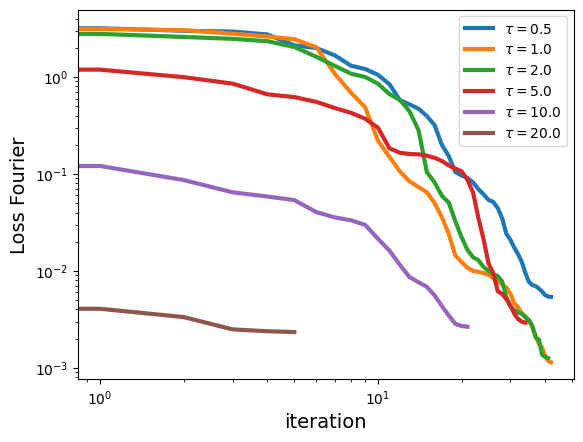

In [22]:
for hist in opt_history:
    print(hist)
    plt.plot(
        6 + np.array(hist),
        linewidth=3,
        label=r"$\tau={:.1f}$".format(taus[opt_history.index(hist)]),
    )
plt.xlabel("iteration", fontsize=14)
plt.ylabel("Loss Fourier", fontsize=14)
plt.legend()
plt.yscale("log")
plt.xscale("log")
plt.show()

##### Cumulative Magic per time evolution

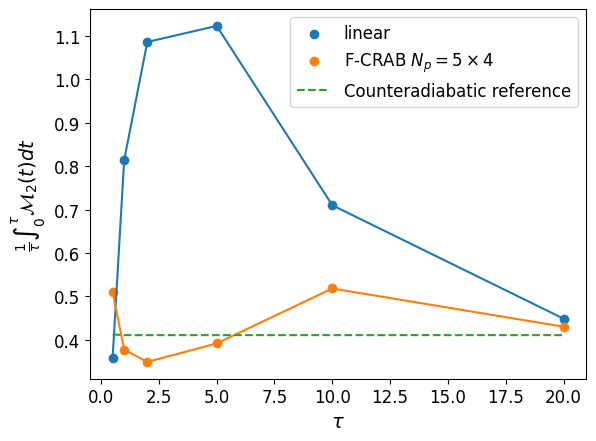

In [23]:
plt.plot(taus, np.array(int_magic_lins) / np.array(taus), color="C0")
plt.scatter(
    taus,
    np.array(int_magic_lins) / np.array(taus),
    label="linear",
    color="C0",
)
plt.plot(taus, np.array(int_magic_opts) / np.array(taus), color="C1")
plt.scatter(
    taus,
    np.array(int_magic_opts) / np.array(taus),
    label=r"F-CRAB $N_p=5 \times 4$",
    color="C1",
)

plt.plot(
    taus,
    np.array(int_magic_gss) / np.array(taus),
    color="C2",
    label=r"Counteradiabatic reference",
    linestyle="--",
)


plt.xlabel(r"$\tau$", fontsize=14)
plt.ylabel(r"$\frac{1}{\tau} \int_0^\tau \mathcal{M}_2(t) dt$", fontsize=14)

plt.tick_params(labelsize=12)
plt.legend(fontsize=12)
plt.show()

##### Entanglement Production

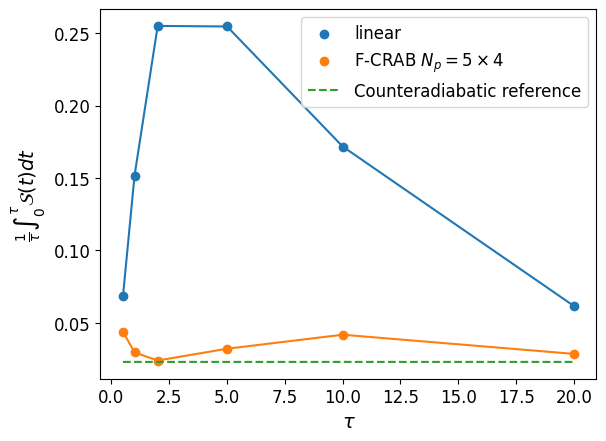

In [24]:
plt.plot(taus, np.array(int_ee_lins) / np.array(taus), color="C0")
plt.scatter(
    taus,
    np.array(int_ee_lins) / np.array(taus),
    label="linear",
    color="C0",
)
plt.plot(taus, np.array(int_ee_opts) / np.array(taus), color="C1")
plt.scatter(
    taus,
    np.array(int_ee_opts) / np.array(taus),
    label=r"F-CRAB $N_p=5 \times 4$",
    color="C1",
)

plt.plot(
    taus,
    np.array(int_ee_gss) / np.array(taus),
    color="C2",
    label=r"Counteradiabatic reference",
    linestyle="--",
)


plt.xlabel(r"$\tau$", fontsize=14)
plt.ylabel(r"$\frac{1}{\tau} \int_0^\tau \mathcal{S}(t) dt$", fontsize=14)

plt.tick_params(labelsize=12)
plt.legend(fontsize=12)
plt.show()

#### SoftPlus + Fourier case

##### Data

In [6]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

# ── load ──────────────────────────────────────────────────────────────────────
with open("results/study_vs_tau_n6_np5_positive fourier.pkl", "rb") as f:
    data = pickle.load(f)

results = data["results"]  # list of dicts, one per tau
taus = data["taus"]  # [1.0, 2.0, 5.0, 10.0, 20.0, 50.0]

# ── single result ─────────────────────────────────────────────────────────────
r = results[3]  # e.g. tau=10
time = r["time"]

# trajectories
magic_lin = r["magic_lin"]  # M2 along linear evolution
magic_opt = r["magic_opt"]  # M2 along optimal control
magic_gs = r["magic_gs"]  # M2 of instantaneous GS (adiabatic ref)
ee_lin = r["ee_lin"]  # EE along linear
ee_opt = r["ee_opt"]  # EE along optimal
ee_gs = r["ee_gs"]  # EE of instantaneous GS

# schedules
h_driver = r["h_driver_opt"]
h_target = r["h_target_opt"]

# scalars
fidelity_lin = r["fidelity_lin"]
fidelity_opt = r["fidelity_opt"]
int_magic_lin = r["int_magic_lin"]  # ∫ M2 dt linear
int_magic_opt = r["int_magic_opt"]  # ∫ M2 dt optimal
int_ee_lin = r["int_ee_lin"]
int_ee_opt = r["int_ee_opt"]

# optimizer convergence history
opt_history = [r["opt_energy_history"] for r in results]

# ── scalar quantities vs tau ───────────────────────────────────────────────────
fidelities_lin = [r["fidelity_lin"] for r in results]
fidelities_opt = [r["fidelity_opt"] for r in results]
int_magic_lins = [r["int_magic_lin"] for r in results]
int_magic_opts = [r["int_magic_opt"] for r in results]
int_magic_gss = [r["int_magic_gs"] for r in results]
int_ee_lins = [r["int_ee_lin"] for r in results]
int_ee_opts = [r["int_ee_opt"] for r in results]
int_ee_gss = [r["int_ee_gs"] for r in results]
min_gaps = [r["min_gap"] for r in results]

##### Magic

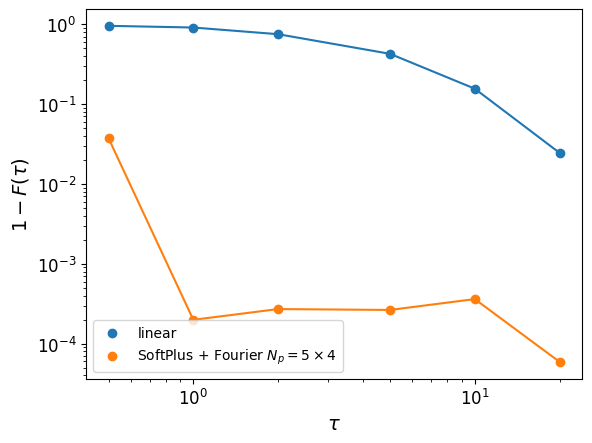

In [11]:
plt.plot(
    taus,
    1 - np.asarray(fidelities_lin),
)
plt.scatter(taus, 1 - np.asarray(fidelities_lin), label="linear", color="C0")
plt.plot(
    taus,
    1 - np.asarray(fidelities_opt),
)
plt.scatter(
    taus,
    1 - np.asarray(fidelities_opt),
    label=r"SoftPlus + Fourier $N_p=5 \times 4$",
    color="C1",
)
plt.xlabel(r"$\tau$", fontsize=14)
plt.ylabel(r"$1-F(\tau)$", fontsize=14)
plt.xscale("log")
plt.yscale("log")
plt.tick_params(labelsize=12)
plt.legend()
plt.show()

##### Losses

[-2.8110318032375208, -2.8898391559641743, -2.93493125258016, -3.050618059574512, -3.106940536114735, -3.1733480775223435, -3.2893548378916284, -3.5601059469228686, -4.070826042476574, -4.836932721703132, -5.250133089228747, -5.37488309531815, -5.468856425605605, -5.579660923146513, -5.6766011793538595, -5.719262283199554, -5.741192242198411, -5.778658996196345, -5.820400566676487, -5.834833622542545, -5.839893690412584, -5.842883681924038, -5.844707326753715, -5.845117738015818, -5.845362762579752, -5.8462649090265435, -5.847200489448455, -5.847341187598993, -5.847593743302007, -5.847683521603551, -5.847748724398588, -5.847975349770664, -5.8485050756669805, -5.8489267573276145, -5.849200016872027, -5.849574956480269, -5.8496585445771325, -5.849815754373687]
[-2.8863793591540614, -2.9484377034019214, -3.201578973829773, -3.2495064285622948, -3.5540946673408884, -3.8952313907072376, -4.077946180152375, -4.446918612554835, -5.288268152199236, -5.560888465035385, -5.738973943510565, -5.82

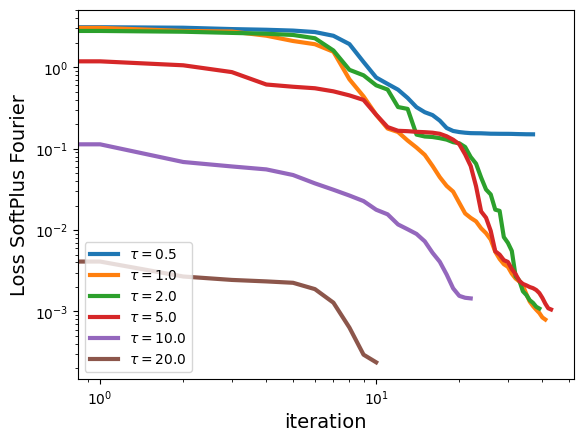

In [12]:
for hist in opt_history:
    print(hist)
    plt.plot(
        6 + np.array(hist),
        linewidth=3,
        label=r"$\tau={:.1f}$".format(taus[opt_history.index(hist)]),
    )
plt.xlabel("iteration", fontsize=14)
plt.ylabel("Loss SoftPlus Fourier", fontsize=14)
plt.legend()
plt.yscale("log")
plt.xscale("log")
plt.show()

##### Cumulative Magic per time evolution

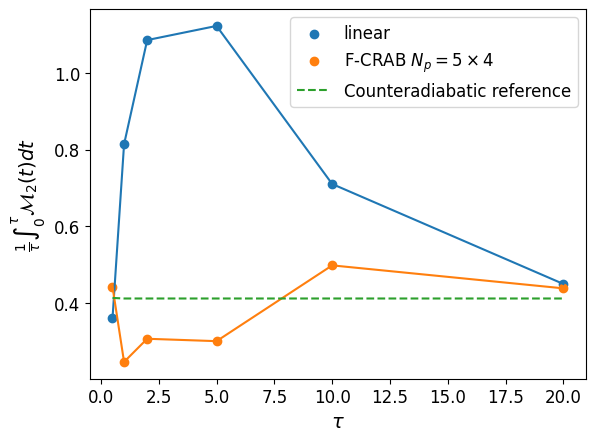

In [9]:
plt.plot(taus, np.array(int_magic_lins) / np.array(taus), color="C0")
plt.scatter(
    taus,
    np.array(int_magic_lins) / np.array(taus),
    label="linear",
    color="C0",
)
plt.plot(taus, np.array(int_magic_opts) / np.array(taus), color="C1")
plt.scatter(
    taus,
    np.array(int_magic_opts) / np.array(taus),
    label=r"F-CRAB $N_p=5 \times 4$",
    color="C1",
)

plt.plot(
    taus,
    np.array(int_magic_gss) / np.array(taus),
    color="C2",
    label=r"Counteradiabatic reference",
    linestyle="--",
)


plt.xlabel(r"$\tau$", fontsize=14)
plt.ylabel(r"$\frac{1}{\tau} \int_0^\tau \mathcal{M}_2(t) dt$", fontsize=14)

plt.tick_params(labelsize=12)
plt.legend(fontsize=12)
plt.show()

##### Entanglement Production

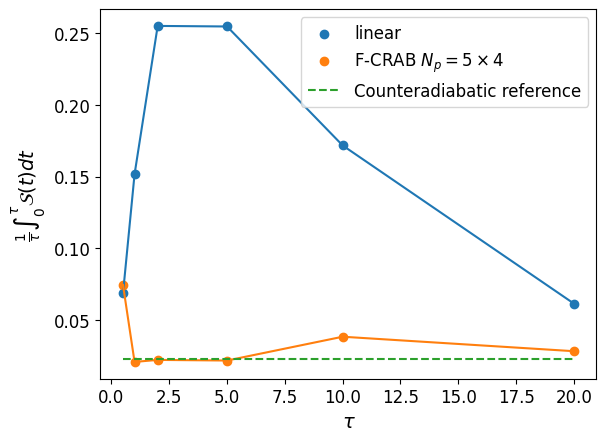

In [10]:
plt.plot(taus, np.array(int_ee_lins) / np.array(taus), color="C0")
plt.scatter(
    taus,
    np.array(int_ee_lins) / np.array(taus),
    label="linear",
    color="C0",
)
plt.plot(taus, np.array(int_ee_opts) / np.array(taus), color="C1")
plt.scatter(
    taus,
    np.array(int_ee_opts) / np.array(taus),
    label=r"F-CRAB $N_p=5 \times 4$",
    color="C1",
)

plt.plot(
    taus,
    np.array(int_ee_gss) / np.array(taus),
    color="C2",
    label=r"Counteradiabatic reference",
    linestyle="--",
)


plt.xlabel(r"$\tau$", fontsize=14)
plt.ylabel(r"$\frac{1}{\tau} \int_0^\tau \mathcal{S}(t) dt$", fontsize=14)

plt.tick_params(labelsize=12)
plt.legend(fontsize=12)
plt.show()

### Analysis with the Number of parameters

#### Fourier Case

##### Data

In [64]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

# ── load ──────────────────────────────────────────────────────────────────────
with open("results/study_vs_params_n6_tau1.0_fourier.pkl", "rb") as f:
    data = pickle.load(f)

results = data["results"]  # list of dicts, one per tau

nparams = np.asarray(data["n_params_list"]) * 4  # [1.0, 2.0, 5.0, 10.0, 20.0, 50.0]

# ── single result ─────────────────────────────────────────────────────────────
r = results[3]  # e.g. tau=10
time = r["time"]

# trajectories
magic_lin = r["magic_lin"]  # M2 along linear evolution
magic_opt = r["magic_opt"]  # M2 along optimal control
magic_gs = r["magic_gs"]  # M2 of instantaneous GS (adiabatic ref)
ee_lin = r["ee_lin"]  # EE along linear
ee_opt = r["ee_opt"]  # EE along optimal
ee_gs = r["ee_gs"]  # EE of instantaneous GS

# schedules
h_driver = r["h_driver_opt"]
h_target = r["h_target_opt"]

# scalars
fidelity_lin = r["fidelity_lin"]
fidelity_opt = r["fidelity_opt"]
int_magic_lin = r["int_magic_lin"]  # ∫ M2 dt linear
int_magic_opt = r["int_magic_opt"]  # ∫ M2 dt optimal
int_ee_lin = r["int_ee_lin"]
int_ee_opt = r["int_ee_opt"]

# optimizer convergence history
opt_history = [r["opt_energy_history"] for r in results]

# ── scalar quantities vs tau ───────────────────────────────────────────────────
fidelities_lin = [r["fidelity_lin"] for r in results]
fidelities_opt = [r["fidelity_opt"] for r in results]
int_magic_lins = [r["int_magic_lin"] for r in results]
int_magic_opts = [r["int_magic_opt"] for r in results]
int_magic_gss = [r["int_magic_gs"] for r in results]
int_ee_lins = [r["int_ee_lin"] for r in results]
int_ee_opts = [r["int_ee_opt"] for r in results]
int_ee_gss = [r["int_ee_gs"] for r in results]
min_gaps = [r["min_gap"] for r in results]

##### Magic

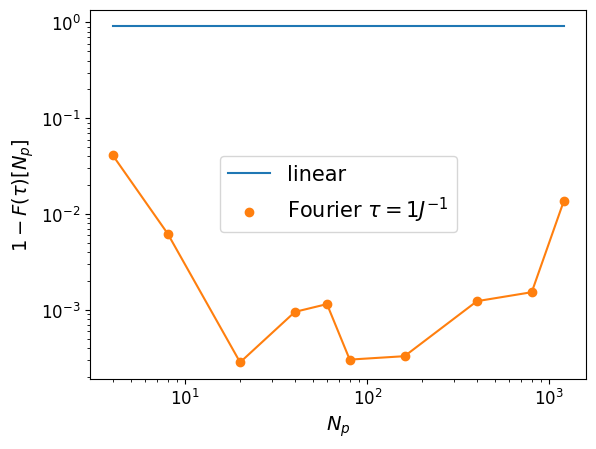

In [66]:
plt.plot(nparams, 1 - np.asarray(fidelities_lin), label="linear")
plt.plot(
    nparams,
    1 - np.asarray(fidelities_opt),
)
plt.scatter(
    nparams,
    1 - np.asarray(fidelities_opt),
    label=r"Fourier $\tau=1 J^{-1}$",
    color="C1",
)
plt.xlabel(r"$N_p$", fontsize=14)
plt.ylabel(r"$1-F(\tau)[N_p]$", fontsize=14)
plt.xscale("log")
plt.yscale("log")
plt.tick_params(labelsize=12)
plt.legend(fontsize=15)
plt.show()

Analysis of the probs for a fixed $\tau$

(20,)


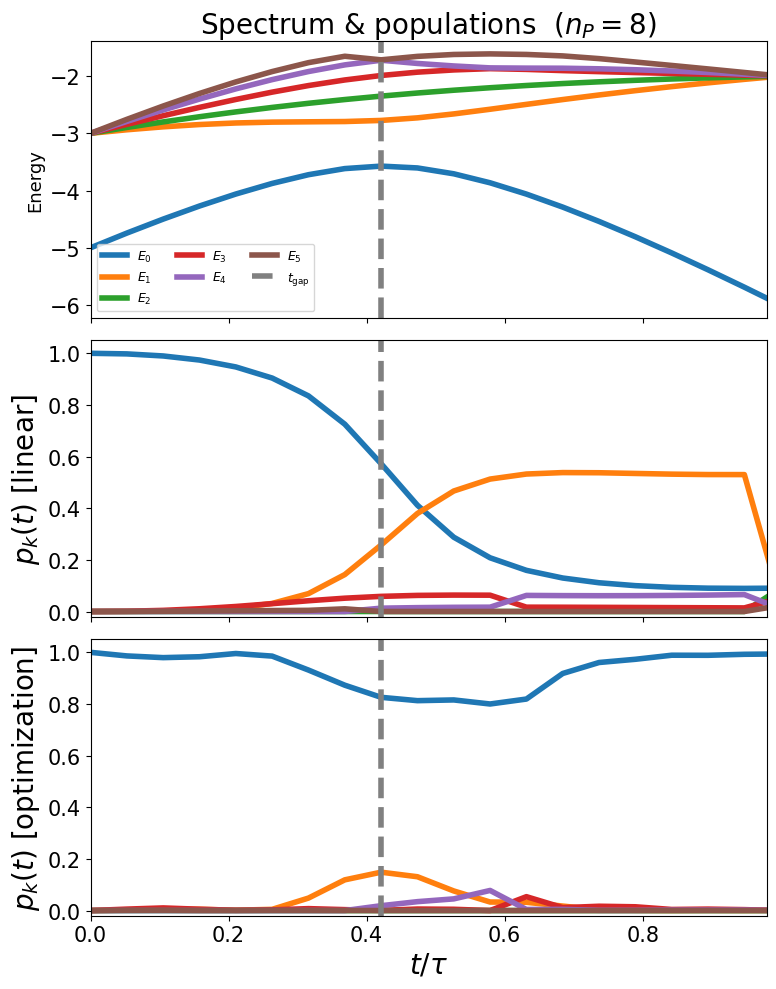

In [67]:
import numpy as np
import matplotlib.pyplot as plt

idx_nparams = 1

r = results[idx_nparams]  # pick your N_p
time = r["time"]

print(time.shape)
spectrum = r["spectrum"]  # (time_steps, nlevels)
probs_lin = r["probs_lin"]  # (time_steps, nlevels)
probs_opt = r["probs_opt"]  # (time_steps, nlevels)
t_gap = r["t_min_gap"]
tau = r["tau"]
nlevels = spectrum.shape[1]  # 6

colors = [f"C{k}" for k in range(nlevels)]
labels = [r"$E_0$", r"$E_1$", r"$E_2$", r"$E_3$", r"$E_4$", r"$E_5$"]

fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

# ── top: energy spectrum ───────────────────────────────────────────────────────
ax = axes[0]
for k in range(nlevels):
    ax.plot(time / tau, spectrum[:, k], color=colors[k], lw=4, label=labels[k])
ax.axvline(t_gap / tau, color="gray", ls="--", lw=4, label=r"$t_{\rm gap}$")
ax.set_ylabel("Energy", fontsize=13)
ax.legend(ncol=3, fontsize=9)
ax.set_title(
    rf"Spectrum & populations  ($n_P={nparams[idx_nparams]:.0f}$)", fontsize=20
)
ax.set_xlim([0, 0.98])
ax.tick_params(labelsize=15)

# ── middle: populations — linear ───────────────────────────────────────────────
ax = axes[1]
for k in range(nlevels):
    ax.plot(time / tau, probs_lin[:, k], color=colors[k], lw=4, label=labels[k])
ax.axvline(t_gap / tau, color="gray", ls="--", lw=4)
ax.set_ylabel(r"$p_k(t)$ [linear]", fontsize=20)
ax.set_ylim(-0.02, 1.05)
ax.set_xlim([0, 0.98])
ax.tick_params(labelsize=15)
# ── bottom: populations — optimal control ──────────────────────────────────────
ax = axes[2]
for k in range(nlevels):
    ax.plot(
        (time) / tau,
        probs_opt[:, k],
        color=colors[k],
        lw=4,
        label=labels[k],
    )
ax.axvline(t_gap / tau, color="gray", ls="--", lw=4)
ax.set_ylabel(r"$p_k(t)$ [optimization]", fontsize=20)
ax.set_ylim(-0.02, 1.05)
ax.set_xlabel(r"$t/\tau$", fontsize=20)
ax.set_xlim([0, 0.98])
ax.tick_params(labelsize=15)

plt.tight_layout()
plt.show()

Comparison with all the $\tau$

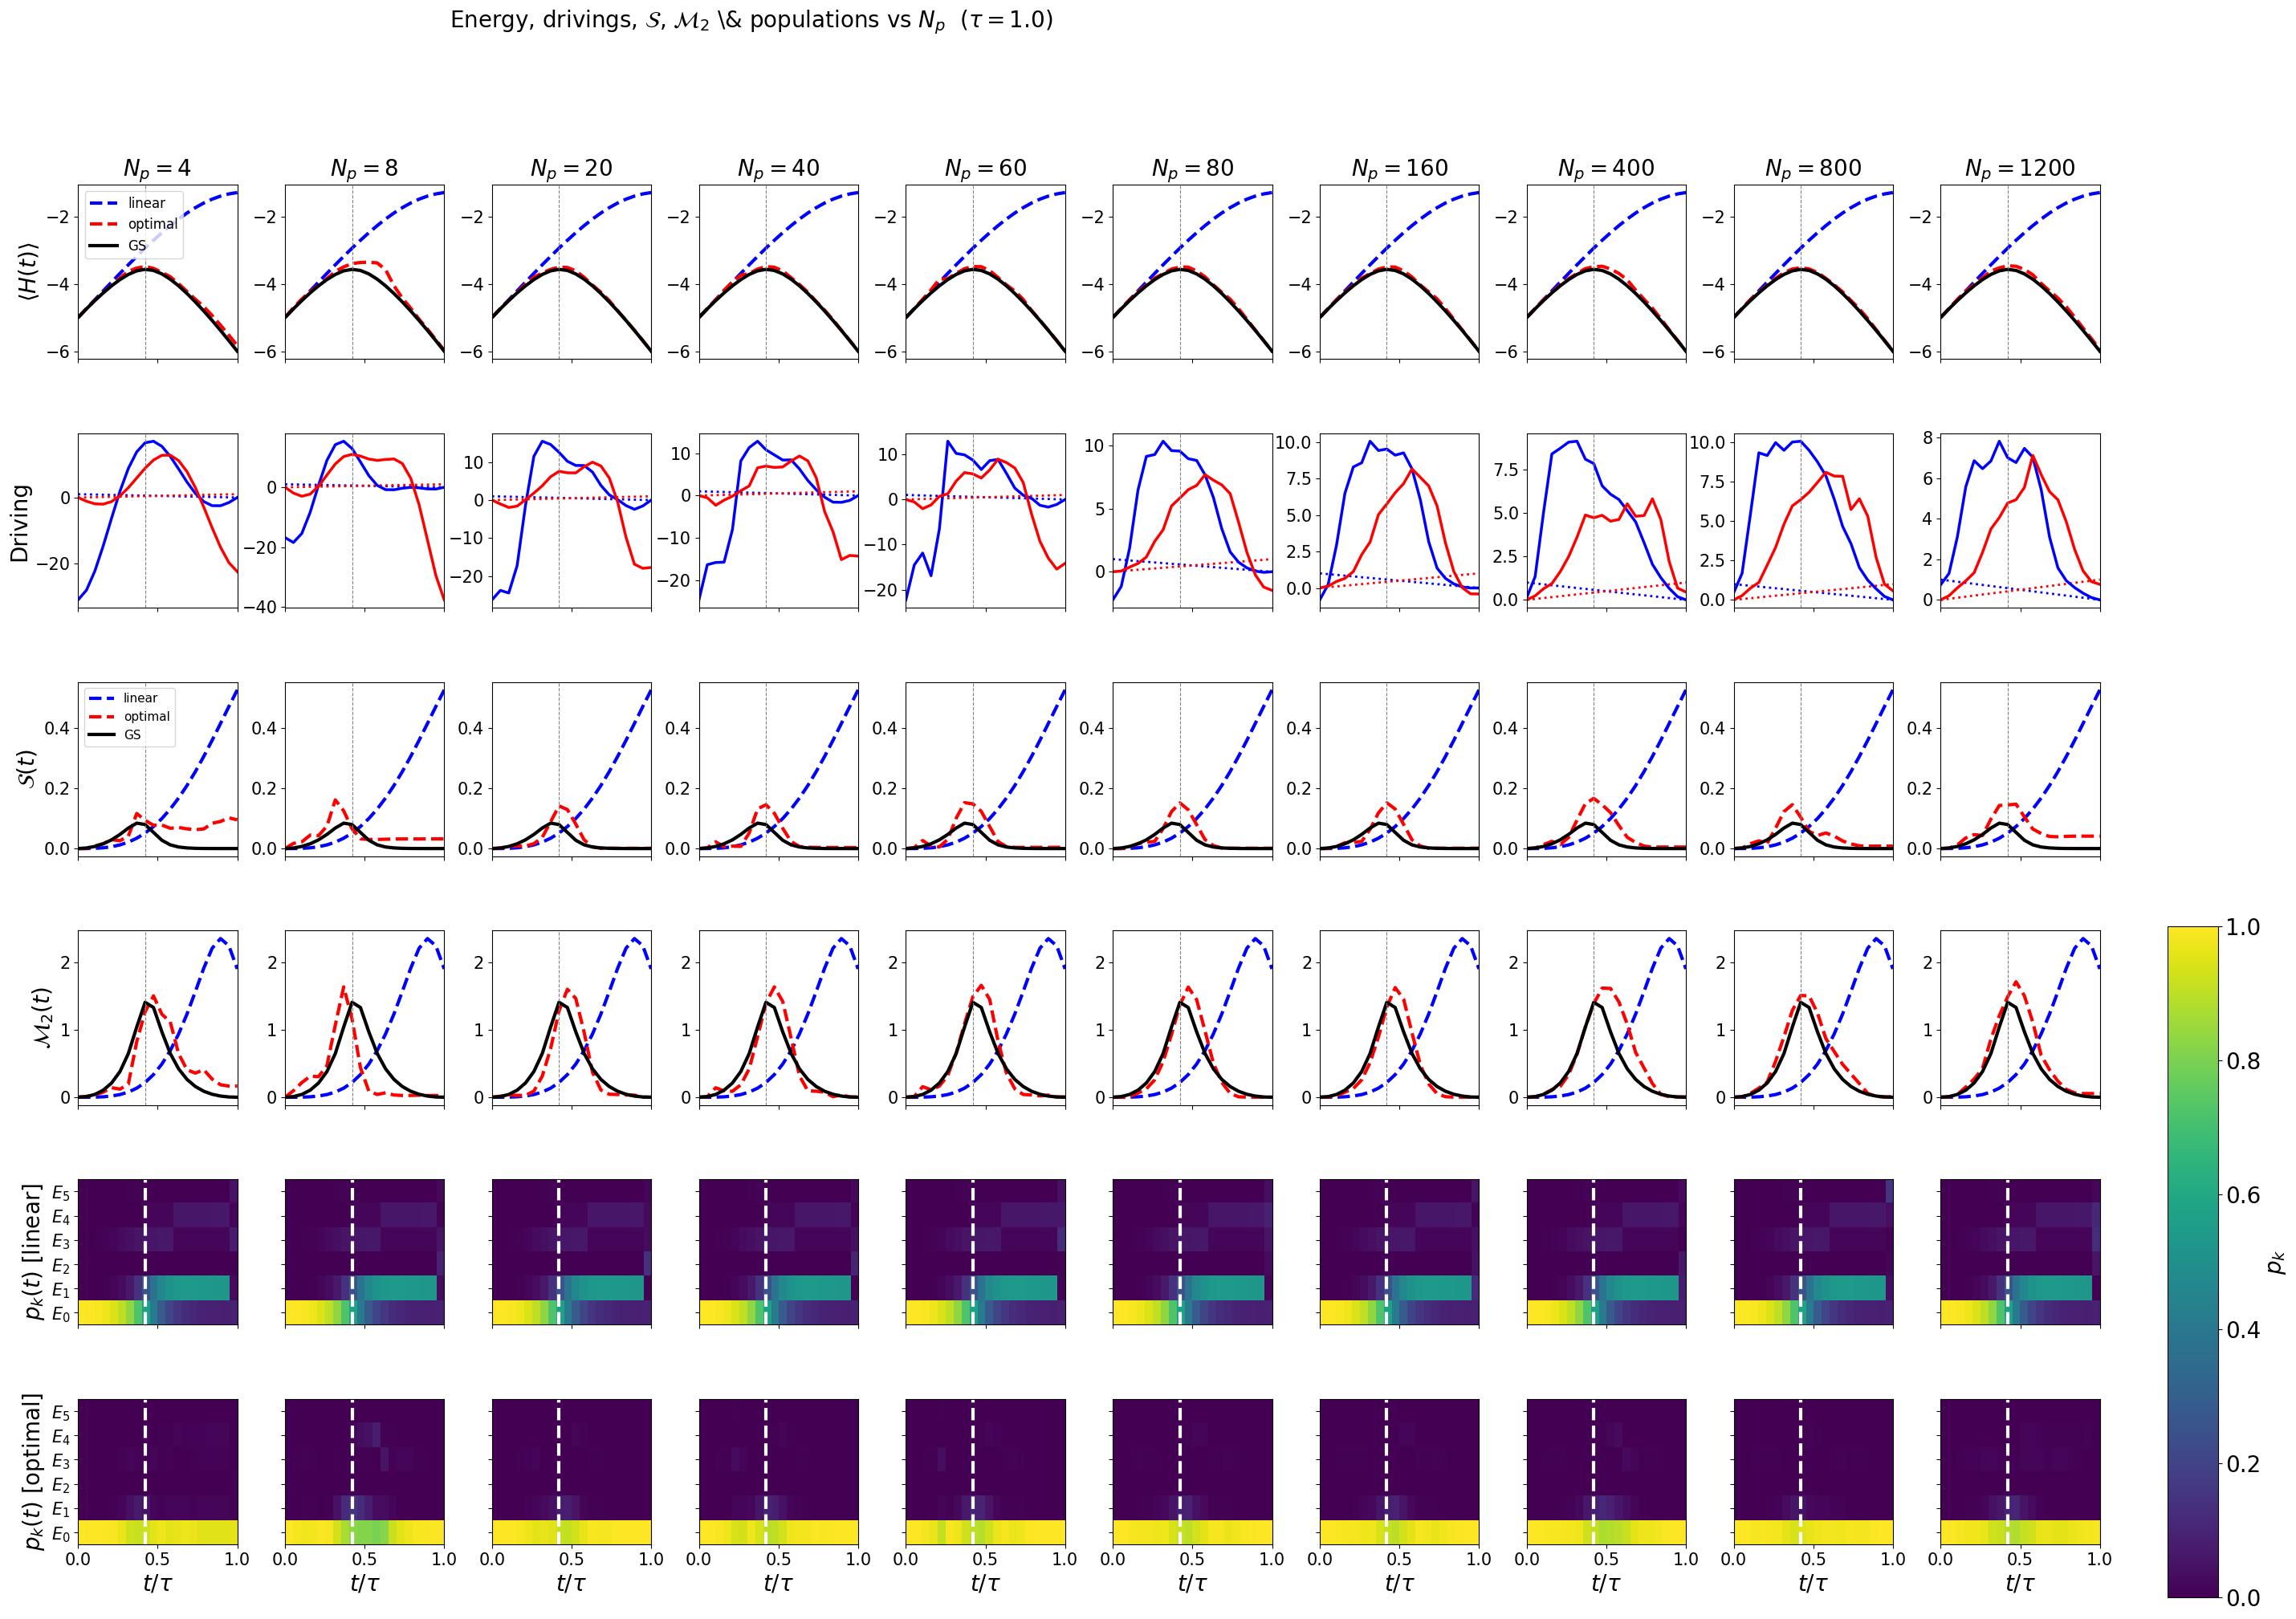

In [68]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# ── config ────────────────────────────────────────────────────────────────────
nlevels = results[0]["spectrum"].shape[1]
colors = [f"C{k}" for k in range(nlevels)]
labels = [rf"$E_{k}$" for k in range(nlevels)]
n_cols = len(results)
tau = results[0]["tau"]  # fixed, shared across all

# ── figure layout ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(2 + 4 * n_cols, 22))
outer = gridspec.GridSpec(1, 2, width_ratios=[1, n_cols], wspace=0.35)

gs = gridspec.GridSpecFromSubplotSpec(
    6,
    n_cols,
    subplot_spec=outer[1],
    height_ratios=[1.2, 1.2, 1.2, 1.2, 1, 1],
    hspace=0.45,
    wspace=0.3,
)

# ── row 0: energy E(t) ───────────────────────────────────────────────────────
for j, r in enumerate(results):
    ax = fig.add_subplot(gs[0, j])
    t = r["time"] / tau
    e0 = r["spectrum"][:, 0]
    ax.plot(t, r["energy_lin"], color="blue", lw=3, ls="--", label="linear")
    ax.plot(t, r["energy_opt"], color="red", lw=3, ls="--", label="optimal")
    ax.plot(t, e0, color="k", lw=3, ls="-", label="GS")
    ax.axvline(r["t_min_gap"] / tau, color="gray", ls="--", lw=0.8)
    ax.set_title(rf"$N_p={np.asarray(r['n_params'])*4}$", fontsize=20)
    ax.set_xlim(0, 1)
    if j == 0:
        ax.set_ylabel(r"$\langle H(t)\rangle$", fontsize=20)
        ax.legend(fontsize=12)
    ax.tick_params(labelsize=15)
    ax.set_xticklabels([])

# ── row 1: drivings h_driver / h_target ──────────────────────────────────────
for j, r in enumerate(results):
    ax = fig.add_subplot(gs[1, j])
    t = r["time"] / tau
    ax.plot(t, 1 - t, color="blue", lw=2, ls=":", label=r"$h_\mathrm{drv}$ lin")
    ax.plot(t, t, color="red", lw=2, ls=":", label=r"$h_\mathrm{tgt}$ lin")
    ax.plot(
        t,
        r["h_driver_opt"],
        color="blue",
        lw=2.5,
        ls="-",
        label=r"$h_\mathrm{drv}$ opt",
    )
    ax.plot(
        t, r["h_target_opt"], color="red", lw=2.5, ls="-", label=r"$h_\mathrm{tgt}$ opt"
    )
    ax.axvline(r["t_min_gap"] / tau, color="gray", ls="--", lw=0.8)
    ax.set_xlim(0, 1)
    if j == 0:
        ax.set_ylabel("Driving", fontsize=20)
    ax.tick_params(labelsize=15)
    ax.set_xticklabels([])

# ── row 2: entanglement entropy EE(t) ────────────────────────────────────────
for j, r in enumerate(results):
    ax = fig.add_subplot(gs[2, j])
    t = r["time"] / tau
    ax.plot(t, r["ee_lin"], color="blue", lw=3, ls="--", label="linear")
    ax.plot(t, r["ee_opt"], color="red", lw=3, ls="--", label="optimal")
    ax.plot(t, r["ee_gs"], color="k", lw=3, ls="-", label="GS")
    ax.axvline(r["t_min_gap"] / tau, color="gray", ls="--", lw=0.8)
    ax.set_xlim(0, 1)
    if j == 0:
        ax.set_ylabel(r"$\mathcal{S}(t)$", fontsize=20)
        ax.legend(fontsize=11)
    ax.tick_params(labelsize=15)
    ax.set_xticklabels([])

# ── row 3: magic M2(t) ───────────────────────────────────────────────────────
for j, r in enumerate(results):
    ax = fig.add_subplot(gs[3, j])
    t = r["time"] / tau
    ax.plot(t, r["magic_lin"], color="blue", lw=3, ls="--", label="linear")
    ax.plot(t, r["magic_opt"], color="red", lw=3, ls="--", label="optimal")
    ax.plot(t, r["magic_gs"], color="k", lw=3, ls="-", label="GS")
    ax.axvline(r["t_min_gap"] / tau, color="gray", ls="--", lw=0.8)
    ax.set_xlim(0, 1)
    if j == 0:
        ax.set_ylabel(r"$\mathcal{M}_2(t)$", fontsize=20)
    ax.tick_params(labelsize=15)
    ax.set_xticklabels([])

# ── rows 4-5: heatmaps of p_k(t) ─────────────────────────────────────────────
for row_idx, (proto_key, proto_label) in enumerate(
    [("probs_lin", "linear"), ("probs_opt", "optimal")], start=4
):
    for j, r in enumerate(results):
        ax = fig.add_subplot(gs[row_idx, j])
        probs = r[proto_key].T
        t = r["time"] / tau
        ax.imshow(
            probs,
            aspect="auto",
            origin="lower",
            extent=[t[0], t[-1], -0.5, nlevels - 0.5],
            vmin=0,
            vmax=1,
            cmap="viridis",
        )
        ax.axvline(r["t_min_gap"] / tau, color="white", ls="--", lw=3)
        ax.set_yticks(range(nlevels))
        ax.set_xlim(0, 1)
        if j == 0:
            ax.set_yticklabels([rf"$E_{k}$" for k in range(nlevels)], fontsize=8)
            ax.set_ylabel(r"$p_k(t)$" + f" [{proto_label}]", fontsize=20)
        else:
            ax.set_yticklabels([])
        if row_idx == 5:
            ax.set_xlabel(r"$t/\tau$", fontsize=20)
        else:
            ax.set_xticklabels([])
        ax.tick_params(labelsize=15)

# shared colorbar for heatmaps
cbar_ax = fig.add_axes([0.92, 0.08, 0.015, 0.38])
cb = fig.colorbar(
    ScalarMappable(norm=Normalize(0, 1), cmap="viridis"),
    cax=cbar_ax,
    label=r"$p_k$",
)
cb.ax.tick_params(labelsize=20)
cb.ax.yaxis.label.set_size(20)

plt.suptitle(
    rf"Energy, drivings, $\mathcal{{S}}$, $\mathcal{{M}}_2$ \& populations vs $N_p$  ($\tau={tau:.1f}$)",
    fontsize=20,
    y=0.98,
)
plt.savefig("spectrum_probs_vs_nparams.pdf", bbox_inches="tight")
plt.show()

##### Losses

[-2.246824567287871, -2.7691618183364444, -2.888560734128506, -3.0075522978942293, -3.1676253093067506, -3.292994278821297, -5.090965177992893, -5.558625775084839, -5.573484506688477, -5.734146228454715, -5.75026185583747, -5.758017961950936, -5.7656044631584935, -5.797993265705264, -5.8147407199292624, -5.833110000003911, -5.834325078408013, -5.834522083766806, -5.834773020924013, -5.835166073555997, -5.835488125552007, -5.83553803890166]
[-2.7563492699846406, -2.9445383648965286, -3.167850464053123, -3.2528707966560155, -3.5862415729742296, -4.647426203133894, -5.004813950847313, -5.478994919092829, -5.694786084802072, -5.809503764982855, -5.844236037554122, -5.852041339700713, -5.857137929230829, -5.860331631743955, -5.88906937994358, -5.8898027127160155, -5.909019338056068, -5.931662811107619, -5.934331952007536, -5.936170053146859, -5.937362220503015, -5.937728909738552, -5.938261865062992, -5.939001675468044, -5.939738782133448, -5.94038830019437, -5.942408499955196, -5.945296335

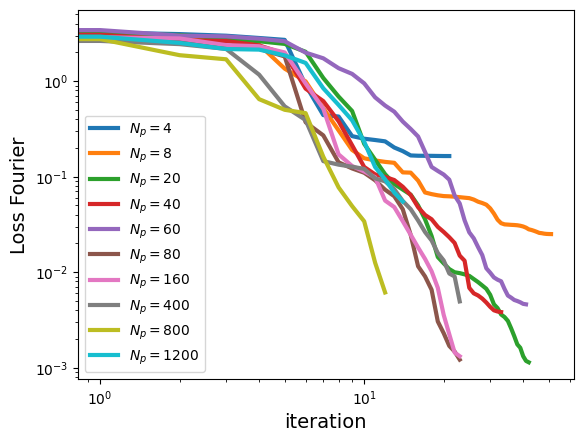

In [69]:
for hist in opt_history:
    print(hist)
    plt.plot(
        6 + np.array(hist),
        linewidth=3,
        label=r"$N_p={:.0f}$".format(nparams[opt_history.index(hist)]),
    )
plt.xlabel("iteration", fontsize=14)
plt.ylabel("Loss Fourier", fontsize=14)
plt.legend()
plt.yscale("log")
plt.xscale("log")
plt.show()

##### Cumulative Magic per time evolution

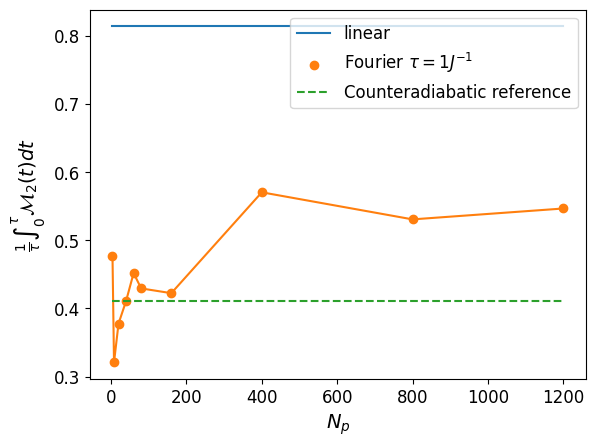

In [72]:
plt.plot(nparams, np.array(int_magic_lins) / tau, color="C0", label="linear")

plt.plot(nparams, np.array(int_magic_opts) / tau, color="C1")
plt.scatter(
    nparams,
    np.array(int_magic_opts) / tau,
    label=r"Fourier $\tau = 1 J^{-1}$",
    color="C1",
)

plt.plot(
    nparams,
    np.array(int_magic_gss) / tau,
    color="C2",
    label=r"Counteradiabatic reference",
    linestyle="--",
)


plt.xlabel(r"$N_p$", fontsize=14)
plt.ylabel(r"$\frac{1}{\tau} \int_0^\tau \mathcal{M}_2(t) dt$", fontsize=14)

plt.tick_params(labelsize=12)
plt.legend(fontsize=12)
plt.show()

##### Entanglement Production

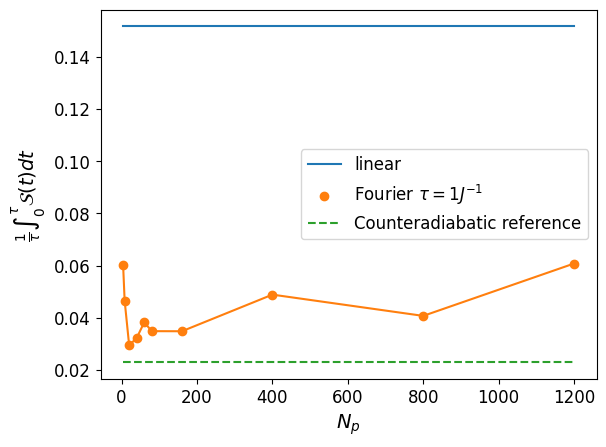

In [74]:
plt.plot(nparams, np.array(int_ee_lins) / tau, color="C0", label="linear")
plt.plot(nparams, np.array(int_ee_opts) / tau, color="C1")
plt.scatter(
    nparams,
    np.array(int_ee_opts) / tau,
    label=r"Fourier $\tau= 1 J^{-1}$",
    color="C1",
)

plt.plot(
    nparams,
    np.array(int_ee_gss) / tau,
    color="C2",
    label=r"Counteradiabatic reference",
    linestyle="--",
)


plt.xlabel(r"$N_p$", fontsize=14)
plt.ylabel(r"$\frac{1}{\tau} \int_0^\tau \mathcal{S}(t) dt$", fontsize=14)

plt.tick_params(labelsize=12)
plt.legend(fontsize=12)
plt.show()

## MaxCut

Loaded 20 instances  (tau=10.0)
Gap range: 0.0002 … 0.0362


/tmp/ipykernel_69730/2105043314.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("plasma")


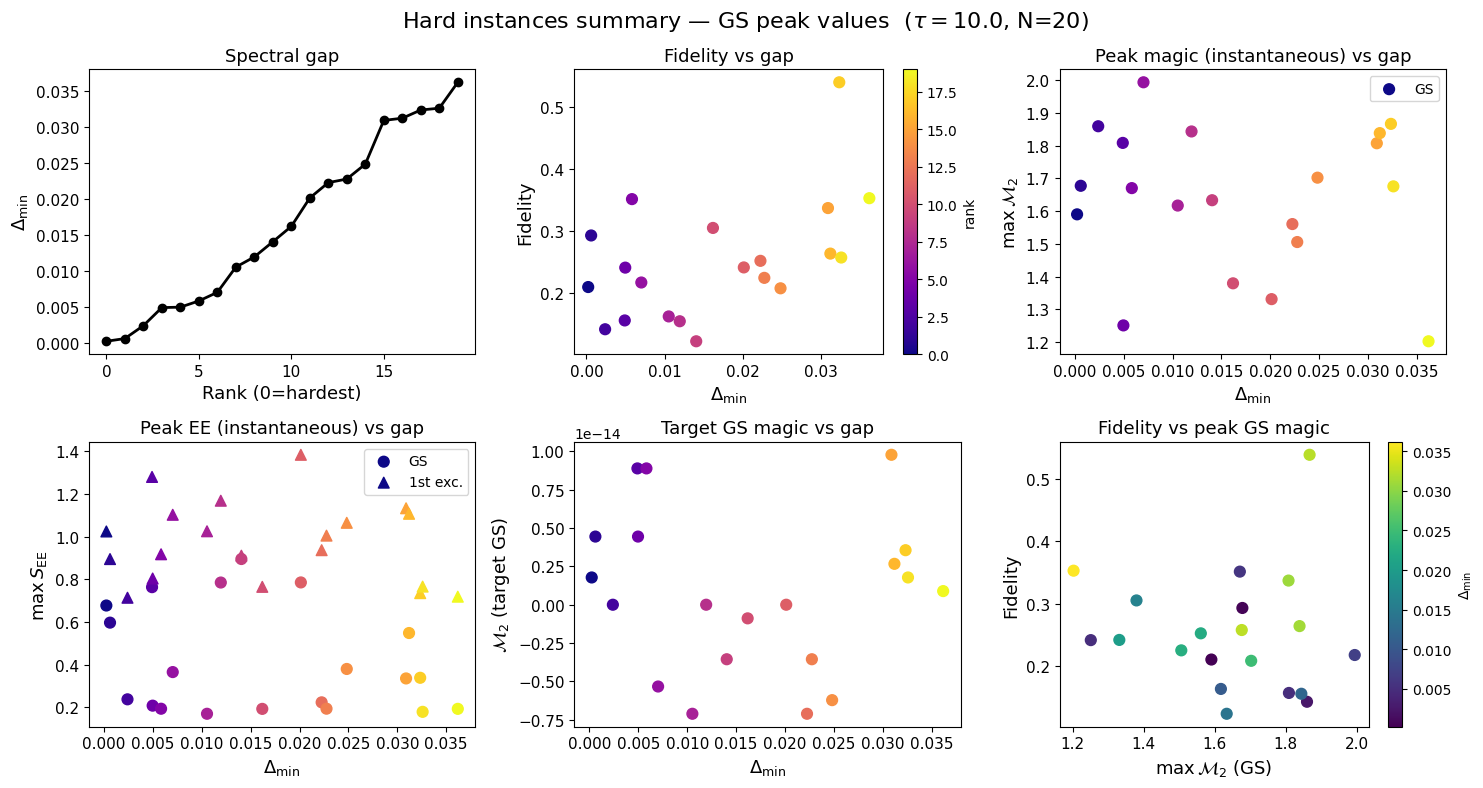

In [95]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable, get_cmap

# ── load ──────────────────────────────────────────────────────────────────────
with open("data/hard_instances.pkl", "rb") as f:
    results = pickle.load(f)

n_instances = len(results)
tau = results[0]["tau"]
time = results[0]["time"]
t = time / tau

print(f"Loaded {n_instances} instances  (tau={tau})")
print(f"Gap range: {results[0]['min_gap']:.4f} … {results[-1]['min_gap']:.4f}")

cmap = get_cmap("plasma")
instance_colors = [cmap(i / (n_instances - 1)) for i in range(n_instances)]

# ═════════════════════════════════════════════════════════════════════════════
# Figure 1 — scalar summary with MAX instead of integral
# ═════════════════════════════════════════════════════════════════════════════
gaps = [r["min_gap"] for r in results]
fidelities = [r["fidelity"] for r in results]
max_magic = [np.max(r["magic_evolution"]) for r in results]
max_magic_gs = [np.max(r["magic_gs"]) for r in results]
max_ee = [np.max(r["ee_evolution"]) for r in results]
max_ee_gs = [np.max(r["ee_gs"]) for r in results]
mg_target = [r["magic_gs_target"] for r in results]
ranks = [r["rank"] for r in results]

max_magic_gs = [np.max(r["magic_gs"]) for r in results]
max_magic_ex = [np.max(r["magic_ex"]) for r in results]
max_ee_gs = [np.max(r["ee_gs"]) for r in results]
max_ee_ex = [np.max(r["ee_ex"]) for r in results]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle(
    rf"Hard instances summary — GS peak values  ($\tau={tau:.1f}$, N={n_instances})",
    fontsize=16,
)

# gap vs rank
ax = axes[0, 0]
ax.plot(ranks, gaps, "o-", color="k", lw=2)
ax.set_xlabel("Rank (0=hardest)", fontsize=13)
ax.set_ylabel(r"$\Delta_{\rm min}$", fontsize=13)
ax.set_title("Spectral gap", fontsize=13)
ax.tick_params(labelsize=11)

# fidelity vs gap
ax = axes[0, 1]
sc = ax.scatter(gaps, fidelities, c=ranks, cmap="plasma", s=60, zorder=3)
plt.colorbar(sc, ax=ax, label="rank")
ax.set_xlabel(r"$\Delta_{\rm min}$", fontsize=13)
ax.set_ylabel("Fidelity", fontsize=13)
ax.set_title("Fidelity vs gap", fontsize=13)
ax.tick_params(labelsize=11)

# peak magic GS vs gap
ax = axes[0, 2]
ax.scatter(gaps, max_magic_gs, c=ranks, cmap="plasma", s=60, label="GS")

ax.set_xlabel(r"$\Delta_{\rm min}$", fontsize=13)
ax.set_ylabel(r"$\max\, \mathcal{M}_2$", fontsize=13)
ax.set_title("Peak magic (instantaneous) vs gap", fontsize=13)
ax.legend(fontsize=10)
ax.tick_params(labelsize=11)

# peak EE GS vs gap
ax = axes[1, 0]
ax.scatter(gaps, max_ee_gs, c=ranks, cmap="plasma", s=60, label="GS")
ax.scatter(gaps, max_ee_ex, c=ranks, cmap="plasma", s=60, marker="^", label="1st exc.")
ax.set_xlabel(r"$\Delta_{\rm min}$", fontsize=13)
ax.set_ylabel(r"$\max\, S_{\rm EE}$", fontsize=13)
ax.set_title("Peak EE (instantaneous) vs gap", fontsize=13)
ax.legend(fontsize=10)
ax.tick_params(labelsize=11)

# target GS magic vs gap
ax = axes[1, 1]
ax.scatter(gaps, mg_target, c=ranks, cmap="plasma", s=60)
ax.set_xlabel(r"$\Delta_{\rm min}$", fontsize=13)
ax.set_ylabel(r"$\mathcal{M}_2$ (target GS)", fontsize=13)
ax.set_title("Target GS magic vs gap", fontsize=13)
ax.tick_params(labelsize=11)

# fidelity vs peak magic GS
ax = axes[1, 2]
ax.scatter(max_magic_gs, fidelities, c=gaps, cmap="viridis", s=60)
plt.colorbar(
    ScalarMappable(norm=Normalize(min(gaps), max(gaps)), cmap="viridis"),
    ax=ax,
    label=r"$\Delta_{\rm min}$",
)
ax.set_xlabel(r"$\max\, \mathcal{M}_2$ (GS)", fontsize=13)
ax.set_ylabel("Fidelity", fontsize=13)
ax.set_title("Fidelity vs peak GS magic", fontsize=13)
ax.tick_params(labelsize=11)

plt.tight_layout()
plt.savefig("hard_instances_summary_peak_gs.pdf", bbox_inches="tight")
plt.show()

#### Let's see the hamming distance

In [96]:
import pickle
import numpy as np
from scipy.sparse.linalg import eigsh
from src.annealing_utils import get_longitudinal_hamiltonian
from src.utils import Sector


def compute_hamming_distance(r, nqubits):
    """
    Compute Hamming distance between GS and 1st excited state
    of the target Hamiltonian for a given instance.
    Since it's a classical Ising Hamiltonian, eigenstates are
    computational basis states — we just find the dominant basis index.
    """
    PS = Sector(nqubits=nqubits)
    jij = r["jij"]

    target_hamiltonian = get_longitudinal_hamiltonian(jij)
    target_hamiltonian_s = PS.project(target_hamiltonian)

    evals, evecs = eigsh(target_hamiltonian_s.astype(complex), which="SA", k=4)
    order = np.argsort(evals)
    evecs = evecs[:, order]

    # dominant basis index in sector for GS and 1st excited
    gs_idx = np.argmax(np.abs(evecs[:, 0]))
    ex_idx = np.argmax(np.abs(evecs[:, 1]))  # skip degenerate partner at idx 1

    # lift sector indices back to full Hilbert space indices
    full_dim = 2**nqubits
    sector_indices = list(range(2 ** (nqubits - 1)))  # Z2 sector
    gs_full_idx = sector_indices[gs_idx]
    ex_full_idx = sector_indices[ex_idx]

    # Hamming distance = number of differing bits
    hamming = bin(gs_full_idx ^ ex_full_idx).count("1")
    return hamming, gs_full_idx, ex_full_idx


# ── compute for all instances ─────────────────────────────────────────────────
nqubits = results[0]["jij"].shape[0]

for r in results:
    hd, gs_idx, ex_idx = compute_hamming_distance(r, nqubits)
    r["hamming_distance"] = hd
    r["gs_bitstring"] = format(gs_idx, f"0{nqubits}b")
    r["ex_bitstring"] = format(ex_idx, f"0{nqubits}b")
    print(
        f"rank {r['rank']}  gap={r['min_gap']:.4f}  "
        f"HD={hd}  GS={r['gs_bitstring']}  EX={r['ex_bitstring']}  "
        f"fidelity={r['fidelity']:.3f}"
    )

Sector: 128 states out of 256
rank 0  gap=0.0002  HD=2  GS=00000111  EX=00100101  fidelity=0.210
Sector: 128 states out of 256
rank 1  gap=0.0006  HD=3  GS=00101110  EX=01000110  fidelity=0.293
Sector: 128 states out of 256
rank 2  gap=0.0024  HD=6  GS=01100011  EX=01011100  fidelity=0.142
Sector: 128 states out of 256
rank 3  gap=0.0049  HD=2  GS=00110110  EX=00010111  fidelity=0.157
Sector: 128 states out of 256
rank 4  gap=0.0050  HD=1  GS=01100101  EX=00100101  fidelity=0.241
Sector: 128 states out of 256
rank 5  gap=0.0058  HD=1  GS=01010110  EX=01110110  fidelity=0.351
Sector: 128 states out of 256
rank 6  gap=0.0070  HD=3  GS=01010011  EX=01100001  fidelity=0.218
Sector: 128 states out of 256
rank 7  gap=0.0105  HD=1  GS=01001100  EX=01001101  fidelity=0.163
Sector: 128 states out of 256
rank 8  gap=0.0119  HD=1  GS=01010001  EX=01010011  fidelity=0.155
Sector: 128 states out of 256
rank 9  gap=0.0140  HD=2  GS=01010110  EX=00011110  fidelity=0.123
Sector: 128 states out of 256


#### Create energy landscape

IndexError: index 128 is out of bounds for axis 0 with size 128

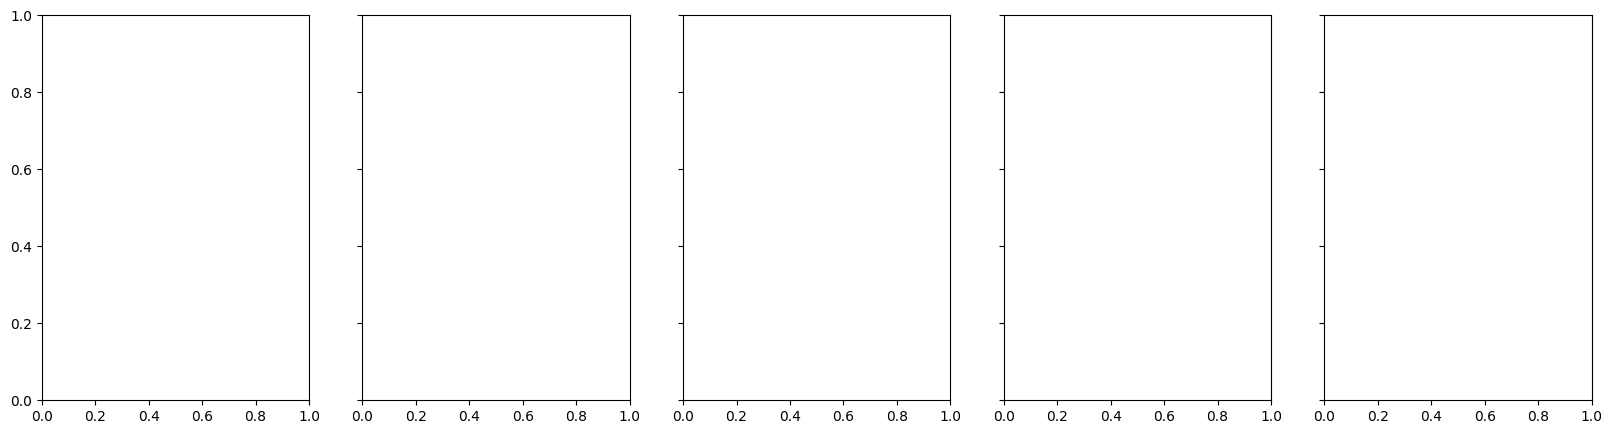

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from src.annealing_utils import computational_basis


def compute_energy_landscape(jij):
    """
    Compute energy of every bitstring for a classical Ising Hamiltonian.
    Returns energies for all 2^n bitstrings.
    """
    nqubits = jij.shape[0]
    basis = computational_basis(nqubits)  # (2^n, n), bits 0/1
    basis = basis[: 2 ** (nqubits - 1)]
    spins = 1 - 2 * basis  # convert 0/1 → +1/-1
    # E(x) = sum_{i<j} J_ij * s_i * s_j
    energies = np.array(
        [
            sum(
                jij[i, j] * spins[x, i] * spins[x, j]
                for i in range(nqubits)
                for j in range(i + 1, nqubits)
            )
            for x in range(2 ** (nqubits - 1))
        ]
    )
    return energies, basis, spins


def hamming_distance(x, y):
    return bin(x ^ y).count("1")


def energy_landscape_by_hamming(jij):
    """
    Returns a dict: hamming_distance → list of energies
    relative to the GS, for all bitstrings at that distance from the GS.
    """
    nqubits = jij.shape[0]
    energies, basis, spins = compute_energy_landscape(jij)

    gs_idx = np.argmin(energies)
    e_gs = energies[gs_idx]

    # for each bitstring compute HD from GS
    landscape = {d: [] for d in range(nqubits + 1)}
    for x in range(2**nqubits):
        hd = hamming_distance(x, gs_idx)
        landscape[hd].append(energies[x] - e_gs)  # relative to GS

    return landscape, gs_idx, e_gs


N_SHOW = min(5, len(results))
nqubits = results[0]["jij"].shape[0]

fig, axes = plt.subplots(1, N_SHOW, figsize=(4 * N_SHOW, 5), sharey=True)

for j, r in enumerate(results[:N_SHOW]):
    ax = axes[j]
    landscape, gs_idx, e_gs = energy_landscape_by_hamming(r["jij"])

    hd_values = []
    min_energies = []

    for hd in range(1, nqubits + 1):
        if landscape[hd]:
            hd_values.append(hd)
            min_energies.append(min(landscape[hd]))

    ax.plot(hd_values, min_energies, "o-", color="C0", lw=2, ms=8, zorder=5)

    # mark where the 1st excited state sits
    hd_ex = hd_values[np.argmin(min_energies)]
    e_ex = min(min_energies)
    ax.axhline(e_ex, color="red", ls="--", lw=1.2, label=rf"1st exc. (HD={hd_ex})")
    ax.axhline(0, color="k", ls="-", lw=1.2, label="GS")

    ax.set_title(
        rf"rank {r['rank']}  seed {r['seed']}"
        + "\n"
        + rf"$\Delta={r['min_gap']:.4f}$  $F={r['fidelity']:.3f}$",
        fontsize=10,
    )
    ax.set_xlabel("Hamming distance from GS", fontsize=12)
    ax.set_xticks(range(1, nqubits + 1))
    if j == 0:
        ax.set_ylabel(r"$\min(E - E_{\rm GS})$", fontsize=12)
    ax.legend(fontsize=8)
    ax.tick_params(labelsize=10)

plt.suptitle(
    "Energy landscape — minimum energy at each Hamming distance from GS",
    fontsize=14,
    y=1.02,
)
plt.loglog()
plt.tight_layout()
plt.savefig("energy_landscape_hamming_min.pdf", bbox_inches="tight")
plt.show()

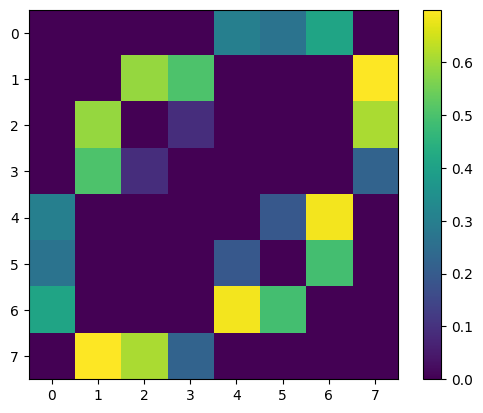

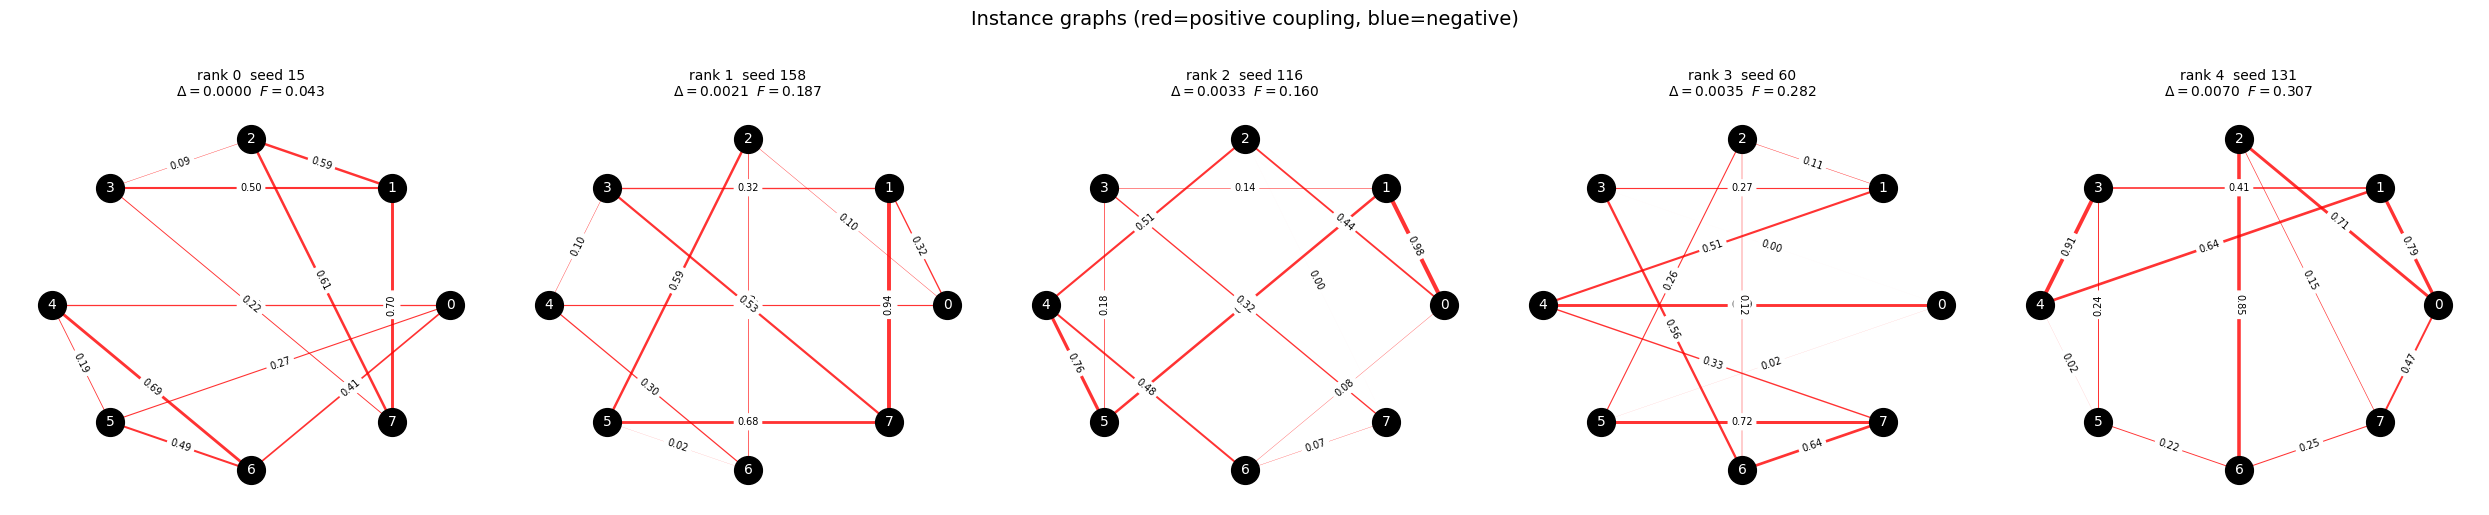

In [93]:
plt.imshow(results[0]["jij"])
plt.colorbar()
plt.show()

import networkx as nx
import matplotlib.pyplot as plt
import numpy as np


def plot_instance_graph(r, ax=None, title=None):
    jij = r["jij"]
    nqubits = jij.shape[0]

    G = nx.Graph()
    G.add_nodes_from(range(nqubits))

    for i in range(nqubits):
        for j in range(i + 1, nqubits):
            if abs(jij[i, j]) > 1e-10:
                G.add_edge(i, j, weight=jij[i, j])

    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))

    pos = nx.circular_layout(G)
    weights = [G[u][v]["weight"] for u, v in G.edges()]

    # colour edges by weight (positive=red, negative=blue)
    edge_colors = ["red" if w > 0 else "blue" for w in weights]
    edge_widths = [abs(w) * 3 for w in weights]

    nx.draw_networkx_nodes(G, pos, ax=ax, node_color="k", node_size=400)
    nx.draw_networkx_labels(G, pos, ax=ax, font_color="white", font_size=10)
    nx.draw_networkx_edges(
        G, pos, ax=ax, edge_color=edge_colors, width=edge_widths, alpha=0.8
    )
    edge_labels = {(u, v): f"{G[u][v]['weight']:.2f}" for u, v in G.edges()}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, ax=ax, font_size=7)

    if title:
        ax.set_title(title, fontsize=10)
    ax.axis("off")


# ── plot top N_SHOW instances ─────────────────────────────────────────────────
N_SHOW = min(5, len(results))

fig, axes = plt.subplots(1, N_SHOW, figsize=(5 * N_SHOW, 5))

for j, r in enumerate(results[:N_SHOW]):
    plot_instance_graph(
        r,
        ax=axes[j],
        title=(
            rf"rank {r['rank']}  seed {r['seed']}"
            + "\n"
            + rf"$\Delta={r['min_gap']:.4f}$  $F={r['fidelity']:.3f}$"
        ),
    )

plt.suptitle(
    "Instance graphs (red=positive coupling, blue=negative)", fontsize=14, y=1.02
)
plt.tight_layout()
plt.savefig("instance_graphs.pdf", bbox_inches="tight")
plt.show()